# GS-ERP 3D Classification — Results Analysis

**TCC — UFRGS**

Master analysis notebook for the ERP-ViT 3D Classification TCC.
Loads experiment outputs, generates publication-quality figures, and exports LaTeX tables.
All heavy lifting is delegated to `src/analysis/`; this notebook only calls those functions.

**Experiments covered:**
- `resnet34_hsdc_mn10_seed42` — ResNet-34 + HSDC, ModelNet10, seed 42, OA=91.96%
- `resnet50_swhdc_mn10_seed42` — ResNet-50 + SWHDC, ModelNet10, seed 42, OA=90.75%

**Paper targets (geometric ray-cast ERP):**
- ResNet-34 + HSDC: 97.1% MN10, 93.9% MN40 (HSDC paper Table 2)
- ResNet-50 + SWHDC: 94.1% MN10, 91.9% MN40 (SWHDC paper Table I)

**Key claim of this TCC:** Evaluate the same HSDC/SWHDC distortion-correction blocks
when the input ERP is generated from **3DGS radiance fields** instead of geometric ray-casting.

All figures saved to `experiments/figures/` as `.png` (300 dpi) and `.pdf`.
LaTeX tables saved to `experiments/tables/`.

---
**Sections:**
1. Setup & Imports
2. Load Experiment Runs
2.5. Results Dashboard
3. Accuracy Comparison Bar Chart + Gap Analysis
4. Comparison Tables (+ LaTeX Export)
5. Training Curves (per-run)
5.5. Combined Training Curves
5.6. Generalization Gap Analysis
5.7. Learning Rate Schedule
5.8. Training Efficiency (Epochs to Accuracy Thresholds)
6. Confusion Matrices
7. Per-Class Accuracy
7.5. Per-Class Accuracy Comparison
8. Parameter-Accuracy Pareto Plot
9. ERP Channel Visualisation
10. Grad-CAM Attention Maps
11. Ablation Studies
12. Statistical Significance (McNemar)
13. Multi-Seed Summary

---
## Section 1: Setup & Imports

In [25]:
import sys
import json
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Repository root resolution ---
# This notebook lives in notebooks/; the repo root is one level up.
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repository root : {ROOT}")

# --- Key directories ---
EXPERIMENTS_DIR = ROOT / "experiments"
FIGURES_DIR     = EXPERIMENTS_DIR / "figures"
TABLES_DIR      = EXPERIMENTS_DIR / "tables"
DATA_CACHE_DIR  = ROOT / "data" / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures dir     : {FIGURES_DIR}")
print(f"Tables dir      : {TABLES_DIR}")

# --- src.analysis imports ---
from src.analysis.metrics import (
    compute_accuracy, compute_mean_class_accuracy,
    compute_per_class_accuracy, compute_confusion_matrix,
    classification_summary, mcnemar_test, ema_smooth,
    load_run_metrics, load_test_results, load_predictions,
    class_names_for, MODELNET10_CLASSES, MODELNET40_CLASSES,
)
from src.analysis.visualize import (
    plot_confusion_matrix, plot_training_curves,
    plot_accuracy_comparison, plot_pareto,
    plot_erp_depth, plot_gradcam, plot_ablation,
    plot_per_class_accuracy,
    PARETO_REFERENCE_MN10, PARETO_REFERENCE_MN40,
)
from src.analysis.compare import (
    load_all_runs, build_comparison_table,
    generate_latex_table, compute_multi_seed_stats,
    build_mcnemar_table, find_best_checkpoint,
    LITERATURE_BASELINES,
)

# --- Global matplotlib style ---
matplotlib.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.grid.axis":    "y",
    "grid.alpha":        0.35,
    "grid.linestyle":    "--",
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

# --- Colour palette (accessible, print-safe) ---
COLORS = {
    "hsdc":      "#2166ac",   # blue
    "swhdc":     "#d6604d",   # red-orange
    "reference": "#808080",   # grey
    "proposed":  "#d73027",   # red
    "gap_good":  "#4dac26",   # green (for warmup / positive annotations)
}

# --- Paper targets (geometric ray-cast ERP, from original papers) ---
PAPER_TARGETS = {
    "hsdc_mn10":  97.1,
    "swhdc_mn10": 94.1,
    "hsdc_mn40":  93.9,
    "swhdc_mn40": 91.9,
}


def _get_paper_target(run_name: str):
    """Return paper target OA (%) for a run based on its name."""
    name = run_name.lower()
    if "hsdc" in name and "mn10" in name:
        return PAPER_TARGETS["hsdc_mn10"]
    if "swhdc" in name and "mn10" in name:
        return PAPER_TARGETS["swhdc_mn10"]
    if "hsdc" in name and "mn40" in name:
        return PAPER_TARGETS["hsdc_mn40"]
    if "swhdc" in name and "mn40" in name:
        return PAPER_TARGETS["swhdc_mn40"]
    return None


def _run_style(run_name: str):
    """Return (color, linestyle, short_label) for a run name."""
    name = run_name.lower()
    if "hsdc" in name:
        return COLORS["hsdc"], "-", "ResNet-34+HSDC"
    if "swhdc" in name:
        return COLORS["swhdc"], "-", "ResNet-50+SWHDC"
    return COLORS["reference"], "-", run_name


def _oa_to_pct(oa):
    """Ensure OA is expressed as a percentage (0-100)."""
    if oa is None:
        return float("nan")
    return oa * 100.0 if oa <= 1.0 else float(oa)


def _parse_training_time(run_dir: Path) -> str:
    """Parse total training time from train.log."""
    log_path = run_dir / "train.log"
    if not log_path.exists():
        return "N/A"
    for line in reversed(log_path.read_text(encoding="utf-8").splitlines()):
        if "Total time:" in line:
            m = re.search(r"Total time:\s*(\d+)\s*s\s*\(([\d.]+)\s*min\)", line)
            if m:
                return f"{int(m.group(1))} s ({float(m.group(2)):.1f} min)"
    return "N/A"


random.seed(42)
print("\nSetup complete.")

Repository root : c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification
Figures dir     : c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures
Tables dir      : c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\tables

Setup complete.


---
## Section 2: Load Experiment Runs

In [26]:
# Scan experiments/ for all directories that contain test_results.json.
# 'figures' and 'tables' subdirectories are automatically skipped by load_all_runs().
runs = load_all_runs(EXPERIMENTS_DIR, require_test_results=True)

if not runs:
    print(f"No completed runs found in {EXPERIMENTS_DIR}.")
    print("Expected sub-directories containing metrics.csv and test_results.json.")
else:
    print(f"Found {len(runs)} completed run(s):\n")
    for run_name, entry in runs.items():
        test     = entry.get("test") or {}
        df       = entry.get("metrics_df")
        oa_pct   = _oa_to_pct(test.get("oa"))
        macc_pct = _oa_to_pct(test.get("macc"))
        params   = test.get("params_m", float("nan"))
        best_val = float(df["val_acc"].max()) if df is not None else float("nan")
        n_epochs = int(df["epoch"].max()) if df is not None else 0
        has_pred = entry.get("y_pred") is not None
        print(f"  {run_name}")
        print(f"    Test OA:      {oa_pct:.2f}%")
        print(f"    Test mAcc:    {macc_pct:.2f}%")
        print(f"    Params:       {params:.2f}M")
        print(f"    Epochs:       {n_epochs}")
        print(f"    Best val acc: {best_val:.2f}%  (from metrics.csv, not test set)")
        print(f"    Predictions:  {'available' if has_pred else 'not found'}")
        print()

Found 4 completed run(s):

  resnet34_hsdc_mn10_seed42
    Test OA:      91.96%
    Test mAcc:    91.93%
    Params:       5.47M
    Epochs:       261
    Best val acc: 95.87%  (from metrics.csv, not test set)
    Predictions:  available

  resnet34_hsdc_mn40_seed42
    Test OA:      87.72%
    Test mAcc:    83.99%
    Params:       5.49M
    Epochs:       403
    Best val acc: 88.52%  (from metrics.csv, not test set)
    Predictions:  available

  resnet50_swhdc_mn10_seed42
    Test OA:      90.75%
    Test mAcc:    90.80%
    Params:       23.55M
    Epochs:       200
    Best val acc: 95.62%  (from metrics.csv, not test set)
    Predictions:  available

  resnet50_swhdc_mn40_seed42
    Test OA:      87.19%
    Test mAcc:    83.04%
    Params:       23.61M
    Epochs:       200
    Best val acc: 88.57%  (from metrics.csv, not test set)
    Predictions:  available



---
## Section 2.5: Results Dashboard

In [27]:
if not runs:
    print("No runs to display.")
else:
    dashboard_rows = []
    for run_name, entry in runs.items():
        test     = entry.get("test") or {}
        df       = entry.get("metrics_df")
        run_dir  = entry["run_dir"]

        oa_pct   = _oa_to_pct(test.get("oa"))
        macc_pct = _oa_to_pct(test.get("macc"))
        params_m = test.get("params_m", float("nan"))

        name_lower = run_name.lower()
        dataset  = "MN10" if "mn10" in name_lower else ("MN40" if "mn40" in name_lower else "?")
        n_epochs = int(df["epoch"].max()) if df is not None else 0
        best_val = float(df["val_acc"].max()) if df is not None else float("nan")
        target   = _get_paper_target(run_name)
        gap      = round(target - oa_pct, 2) if (target is not None and not np.isnan(oa_pct)) else float("nan")
        train_time = _parse_training_time(run_dir)

        dashboard_rows.append({
            "Run Name":         run_name,
            "Dataset":          dataset,
            "OA (%)": round(oa_pct, 2),
            "mAcc (%)": round(macc_pct, 2),
            "Params (M)": round(params_m, 2) if params_m is not None else float("nan"),
            "Epochs":           n_epochs,
            "Best Val Acc (%)": round(best_val, 2),
            "Paper Target (%)": target if target is not None else float("nan"),
            "Gap (pp)": gap,
            "Train Time": train_time,
        })

    dash_df = pd.DataFrame(dashboard_rows)

    print("=" * 90)
    print("RESULTS DASHBOARD — GS-ERP 3D Classification (3DGS Radiance Field ERP)")
    print("=" * 90)
    with pd.option_context(
        "display.max_columns", None,
        "display.width", 200,
        "display.float_format", "{:.2f}".format,
    ):
        display(dash_df)

    print("\nNotes:")
    print("  OA / mAcc  : final test-set results (official ModelNet split).")
    print("  Best Val Acc: from validation split during training, NOT the test set.")
    print("  Gap (pp)   : paper_target_OA - test_OA.  Positive means below geometric ERP baseline.")
    print("  Paper targets use geometric ray-cast ERP on raw meshes;")
    print("  these runs use 3DGS radiance field ERP — this TCC's new contribution.")

RESULTS DASHBOARD — GS-ERP 3D Classification (3DGS Radiance Field ERP)


,Run Name,Dataset,OA (%),mAcc (%),Params (M),Epochs,Best Val Acc (%),Paper Target (%),Gap (pp),Train Time
0,resnet34_hsdc_mn10_seed42,MN10,91.96,91.93,5.47,261,95.87,97.10,5.14,7894 s (131.6 min)
1,resnet34_hsdc_mn40_seed42,MN40,87.72,83.99,5.49,403,88.52,93.90,6.18,29492 s (491.5 min)
2,resnet50_swhdc_mn10_seed42,MN10,90.75,90.80,23.55,200,95.62,94.10,3.35,6043 s (100.7 min)
3,resnet50_swhdc_mn40_seed42,MN40,87.19,83.04,23.61,200,88.57,91.90,4.71,14414 s (240.2 min)



Notes:
  OA / mAcc  : final test-set results (official ModelNet split).
  Best Val Acc: from validation split during training, NOT the test set.
  Gap (pp)   : paper_target_OA - test_OA.  Positive means below geometric ERP baseline.
  Paper targets use geometric ray-cast ERP on raw meshes;
  these runs use 3DGS radiance field ERP — this TCC's new contribution.


---
## Section 3: Accuracy Comparison Bar Chart + Gap Analysis

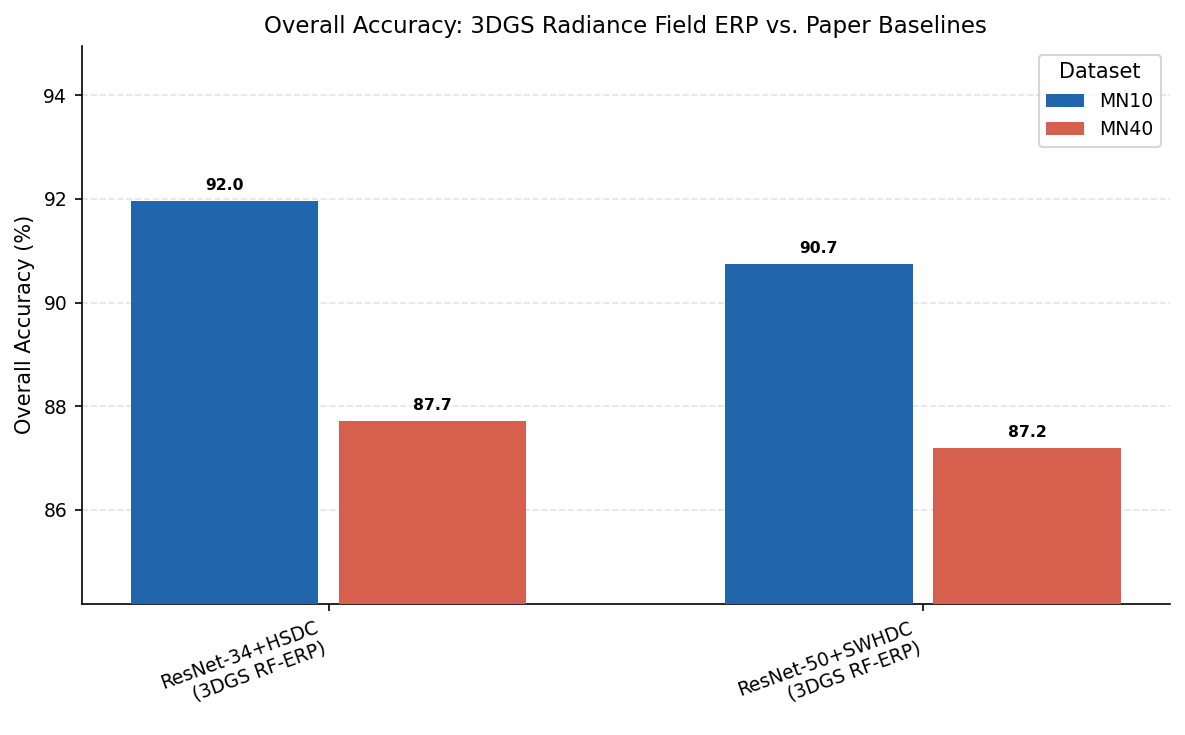

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/accuracy_comparison.*


In [28]:
if not runs:
    print("No runs available for comparison chart.")
else:
    # Build results dict: {run_label: {dataset: oa_pct}}
    results_for_chart = {}
    for run_name, entry in runs.items():
        test = entry.get("test")
        if test is None:
            continue
        oa         = _oa_to_pct(test.get("oa"))
        name_lower = run_name.lower()
        dataset    = "MN10" if "mn10" in name_lower else ("MN40" if "mn40" in name_lower else "?")

        if "resnet34" in name_lower and "hsdc" in name_lower:
            chart_label = "ResNet-34+HSDC\n(3DGS RF-ERP)"
        elif "resnet50" in name_lower and "swhdc" in name_lower:
            chart_label = "ResNet-50+SWHDC\n(3DGS RF-ERP)"
        else:
            chart_label = run_name

        if chart_label not in results_for_chart:
            results_for_chart[chart_label] = {}
        results_for_chart[chart_label][dataset] = oa

    datasets_present = sorted({ds for vals in results_for_chart.values() for ds in vals})

    fig = plot_accuracy_comparison(
        results=results_for_chart,
        datasets=datasets_present,
        metric="oa",
        title="Overall Accuracy: 3DGS Radiance Field ERP vs. Paper Baselines",
        save_path=FIGURES_DIR / "accuracy_comparison",
    )
    plt.show()
    print(f"Saved: {FIGURES_DIR}/accuracy_comparison.*")

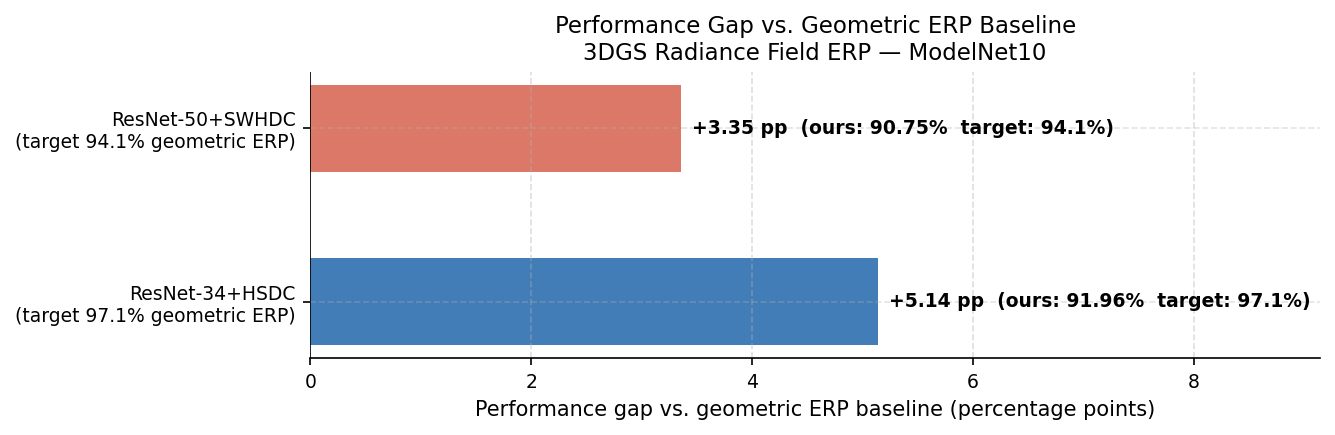

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/gap_analysis_mn10.*

Interpretation for TCC (ModelNet10):
  ResNet-34+HSDC: 91.96% vs 97.1% (+5.14 pp gap)
  ResNet-50+SWHDC: 90.75% vs 94.1% (+3.35 pp gap)



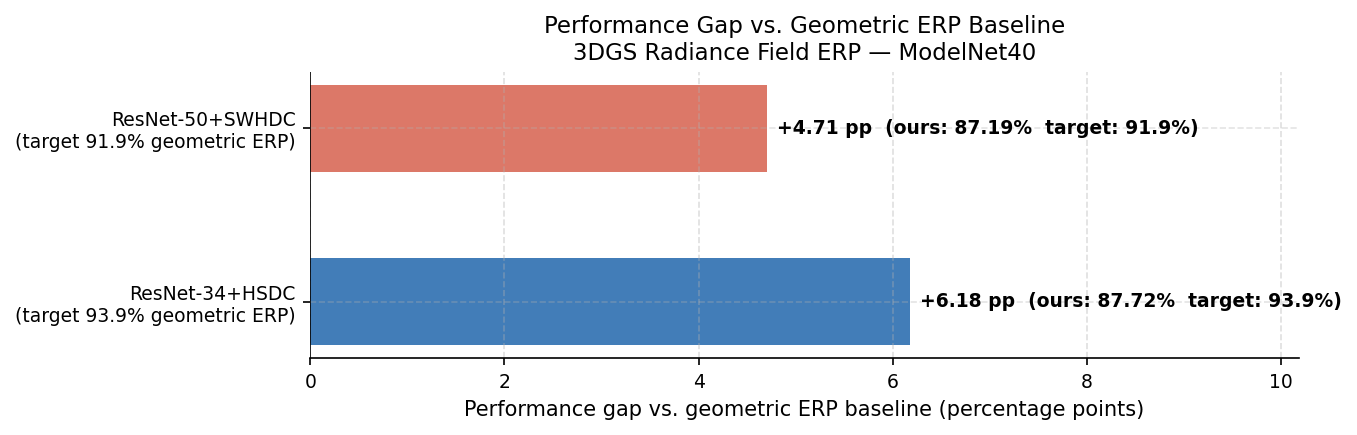

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/gap_analysis_mn40.*

Interpretation for TCC (ModelNet40):
  ResNet-34+HSDC: 87.72% vs 93.9% (+6.18 pp gap)
  ResNet-50+SWHDC: 87.19% vs 91.9% (+4.71 pp gap)

The gap quantifies the information loss from using volumetric radiance
field ERP (3DGS) vs. precise geometric ray-casting on raw mesh files.


In [29]:
# --- Gap analysis: how far are we from the paper's geometric ERP results? ---
# This is TCC-critical: it quantifies the effect of using 3DGS instead of ray-casting.
# Produces separate figures for MN10 and MN40.

if not runs:
    print('No runs available.')
else:
    def _plot_gap_analysis(dataset_tag: str, title_suffix: str) -> None:
        """Plot gap analysis bar chart for one dataset tag ('mn10' or 'mn40')."""
        matching = [
            (run_name, entry)
            for run_name, entry in runs.items()
            if dataset_tag in run_name.lower() and entry.get('test') is not None
        ]
        if not matching:
            print(f'No {dataset_tag.upper()} runs found for gap analysis.')
            return

        gap_labels, gap_values, gap_colors, gap_oas, gap_targets = [], [], [], [], []

        for run_name, entry in matching:
            test   = entry['test']
            oa     = _oa_to_pct(test.get('oa'))
            target = _get_paper_target(run_name)
            if target is None:
                continue
            gap    = target - oa
            color, _, lbl = _run_style(run_name)

            gap_labels.append(f'{lbl}\n(target {target:.1f}% geometric ERP)')
            gap_values.append(gap)
            gap_colors.append(color)
            gap_oas.append(oa)
            gap_targets.append(target)

        if not gap_labels:
            print(f'No paper targets found for {dataset_tag.upper()} runs.')
            return

        fig2, ax2 = plt.subplots(figsize=(9, max(2.5, len(gap_labels) * 1.5)))
        y_pos = np.arange(len(gap_labels))
        bars  = ax2.barh(y_pos, gap_values, color=gap_colors, alpha=0.85, height=0.5)

        for bar, v, oa, tgt in zip(bars, gap_values, gap_oas, gap_targets):
            ax2.text(
                bar.get_width() + 0.1,
                bar.get_y() + bar.get_height() / 2,
                f'+{v:.2f} pp  (ours: {oa:.2f}%  target: {tgt:.1f}%)',
                va='center', fontsize=9, fontweight='bold',
            )

        ax2.axvline(0, color='black', linewidth=0.8)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(gap_labels, fontsize=9)
        ax2.set_xlabel('Performance gap vs. geometric ERP baseline (percentage points)')
        ax2.set_title(
            f'Performance Gap vs. Geometric ERP Baseline\n'
            f'3DGS Radiance Field ERP \u2014 {title_suffix}'
        )
        ax2.set_xlim(0, max(gap_values) + 4)
        ax2.grid(True, axis='x', linestyle='--', alpha=0.4)
        ax2.spines['left'].set_visible(False)

        plt.tight_layout()
        fname = f'gap_analysis_{dataset_tag}'
        for ext in ('png', 'pdf'):
            fig2.savefig(
                FIGURES_DIR / f'{fname}.{ext}',
                dpi=300, bbox_inches='tight',
            )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/{fname}.*')

        print(f'\nInterpretation for TCC ({title_suffix}):')
        for lbl, gap, oa, tgt in zip(gap_labels, gap_values, gap_oas, gap_targets):
            lbl_clean = lbl.split('\n')[0].strip()
            print(f'  {lbl_clean}: {oa:.2f}% vs {tgt:.1f}% ({gap:+.2f} pp gap)')

    _plot_gap_analysis('mn10', 'ModelNet10')
    print()
    _plot_gap_analysis('mn40', 'ModelNet40')

    print()
    print('The gap quantifies the information loss from using volumetric radiance')
    print('field ERP (3DGS) vs. precise geometric ray-casting on raw mesh files.')


---
## Section 4: Comparison Tables (+ LaTeX Export)

In [30]:
# --- MN10 comparison table ---
print("=" * 65)
print("ModelNet10 Comparison Table")
print("=" * 65)

mn10_table = build_comparison_table(runs, dataset="MN10", include_literature=True)

with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", 45,
    "display.float_format", "{:.2f}".format,
    "display.width", 130,
):
    display(mn10_table)

# Export LaTeX
mn10_tex_path = TABLES_DIR / "results_mn10.tex"
mn10_tex = generate_latex_table(
    mn10_table,
    dataset="MN10",
    caption=(
        "3D object classification results on ModelNet10. "
        "OA = Overall Accuracy (\\%), mAcc = Mean Class Accuracy (\\%). "
        "Methods marked with $\\dagger$ use 3DGS radiance field ERP (this work); "
        "others use geometric ray-cast ERP on raw mesh files. "
        "Best result in \\textbf{bold}, second-best \\underline{underlined}."
    ),
    label="tab:results_mn10",
    save_path=mn10_tex_path,
)
print(f"\nLaTeX table saved to: {mn10_tex_path}")
print("\nLaTeX source:")
print("-" * 60)
print(mn10_tex)

ModelNet10 Comparison Table


,method,input,oa,macc,params_m,source
0,HSDCNet (ResNet-34 + HSDC),12-ch ERP,97.10,NaN,5.30,HSDC paper Table 2
1,ResNet-50 + SWHDC,1-ch depth ERP,94.10,NaN,25.50,SWHDC paper Table I
2,ResNet-34 + HSDC,8-shell RF-ERP,91.96,91.93,5.47,this work
3,ResNet-50 + SWHDC,8-shell RF-ERP,90.75,90.80,23.55,this work
4,ResNet-34 + HSDC,8-shell RF-ERP,87.72,83.99,5.49,this work
5,ResNet-50 + SWHDC,8-shell RF-ERP,87.19,83.04,23.61,this work
6,PanoFormer ViT + FC,1-ch depth ERP,85.70,NaN,NaN,SWHDC paper Table III
7,PointMLP,Point cloud,NaN,91.50,12.60,HSDC paper Table 2
8,View-GCN (20 views),Multi-view,NaN,NaN,12.00,HSDC paper Table 2



LaTeX table saved to: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\tables\results_mn10.tex

LaTeX source:
------------------------------------------------------------
% Auto-generated by src/analysis/compare.py
\begin{table}[t]
  \centering
  \caption{3D object classification results on ModelNet10. OA = Overall Accuracy (\%), mAcc = Mean Class Accuracy (\%). Methods marked with $\dagger$ use 3DGS radiance field ERP (this work); others use geometric ray-cast ERP on raw mesh files. Best result in \textbf{bold}, second-best \underline{underlined}.}
  \label{tab:results_mn10}
  \begin{tabular}{llccc}
    \toprule
    \textbf{Method} & \textbf{Input} & \textbf{OA (\%)} & \textbf{mAcc (\%)} & \textbf{Params (M)} \\
    \midrule
    HSDCNet (ResNet-34 + HSDC) & 12-ch ERP & \textbf{97.1} & — & 5.3 \\
    ResNet-50 + SWHDC & 1-ch depth ERP & \underline{94.1} & — & 25.5 \\
    PanoFormer ViT + FC & 1-ch depth ERP & 85.7 & — & — \\
    PointMLP & Point cloud & — & \underline{

In [31]:
# --- MN40 comparison table (literature only until MN40 runs complete) ---
print("=" * 65)
print("ModelNet40 Comparison Table (literature baselines + future runs)")
print("=" * 65)

mn40_table = build_comparison_table(runs, dataset="MN40", include_literature=True)

with pd.option_context(
    "display.max_columns", None,
    "display.float_format", "{:.2f}".format,
    "display.width", 130,
):
    display(mn40_table)

mn40_tex_path = TABLES_DIR / "results_mn40.tex"
mn40_tex = generate_latex_table(
    mn40_table,
    dataset="MN40",
    save_path=mn40_tex_path,
)
print(f"LaTeX table saved to: {mn40_tex_path}")

ModelNet40 Comparison Table (literature baselines + future runs)


,method,input,oa,macc,params_m,source
0,View-GCN (20 views),Multi-view,97.60,NaN,12.00,HSDC paper Table 2
1,PointMLP,Point cloud,94.50,91.50,12.60,HSDC paper Table 2
2,HSDCNet (ResNet-34 + HSDC),12-ch ERP,93.90,NaN,5.30,HSDC paper Table 2
3,ResNet-34 + HSDC,8-shell RF-ERP,91.96,91.93,5.47,this work
4,ResNet-50 + SWHDC,1-ch depth ERP,91.90,NaN,25.50,SWHDC paper Table I
5,ResNet-50 + SWHDC,8-shell RF-ERP,90.75,90.80,23.55,this work
6,ResNet-34 + HSDC,8-shell RF-ERP,87.72,83.99,5.49,this work
7,ResNet-50 + SWHDC,8-shell RF-ERP,87.19,83.04,23.61,this work
8,PanoFormer ViT + FC,1-ch depth ERP,79.70,NaN,NaN,SWHDC paper Table III


LaTeX table saved to: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\tables\results_mn40.tex


---
## Section 5: Training Curves (Per-Run)

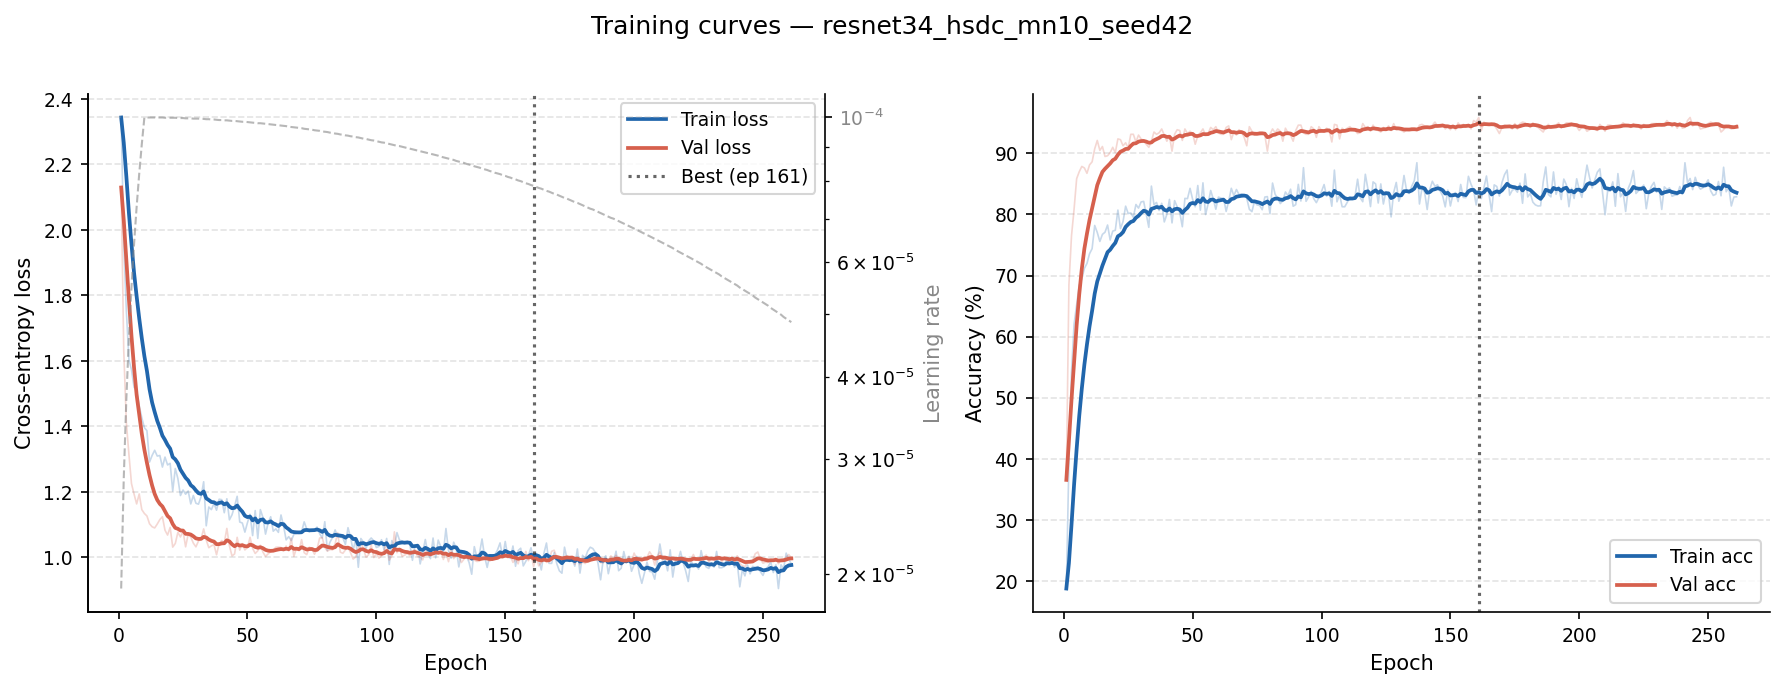

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_resnet34_hsdc_mn10_seed42.*  (best ep: 161)



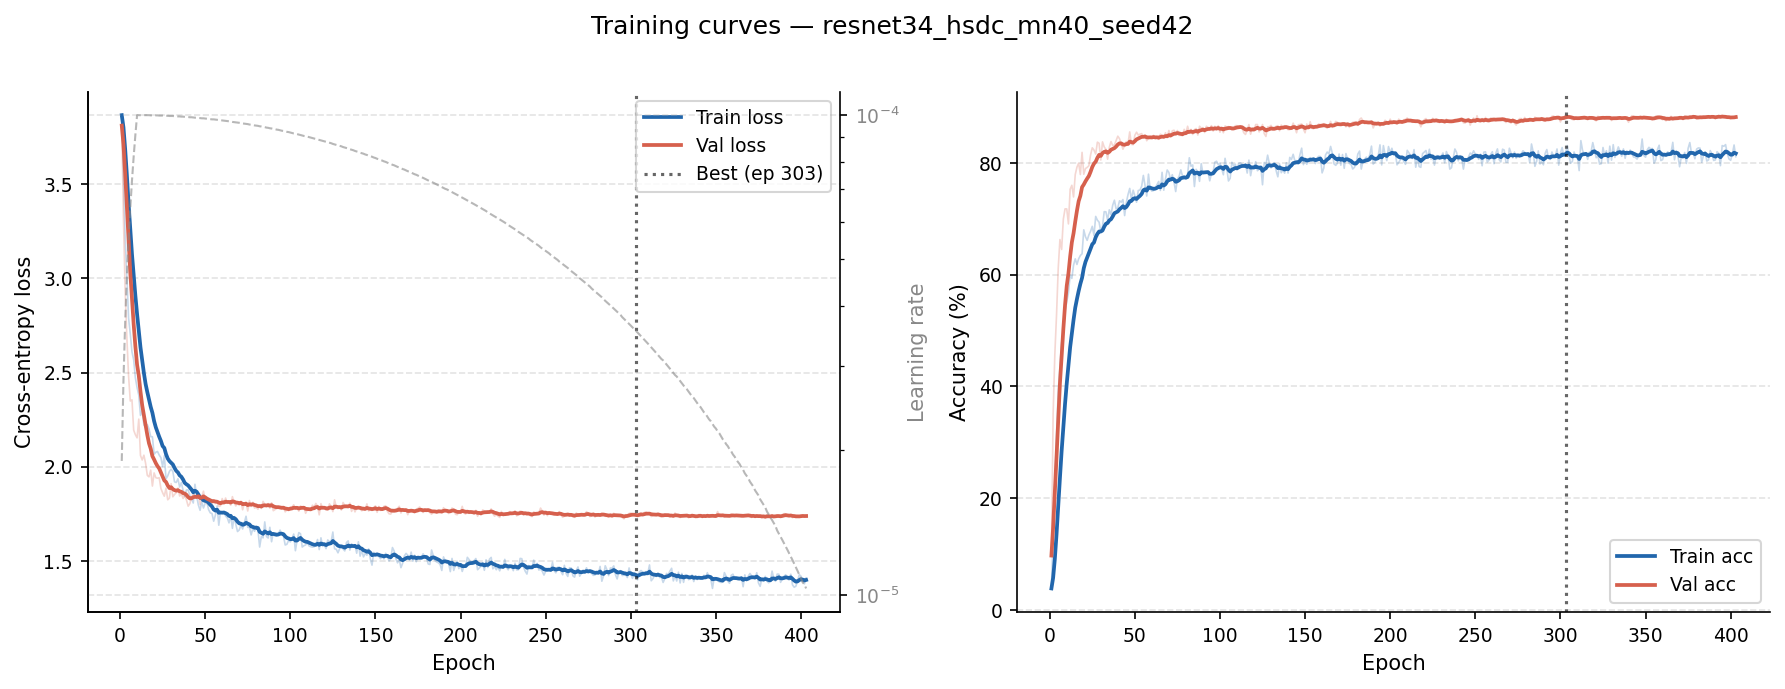

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_resnet34_hsdc_mn40_seed42.*  (best ep: 303)



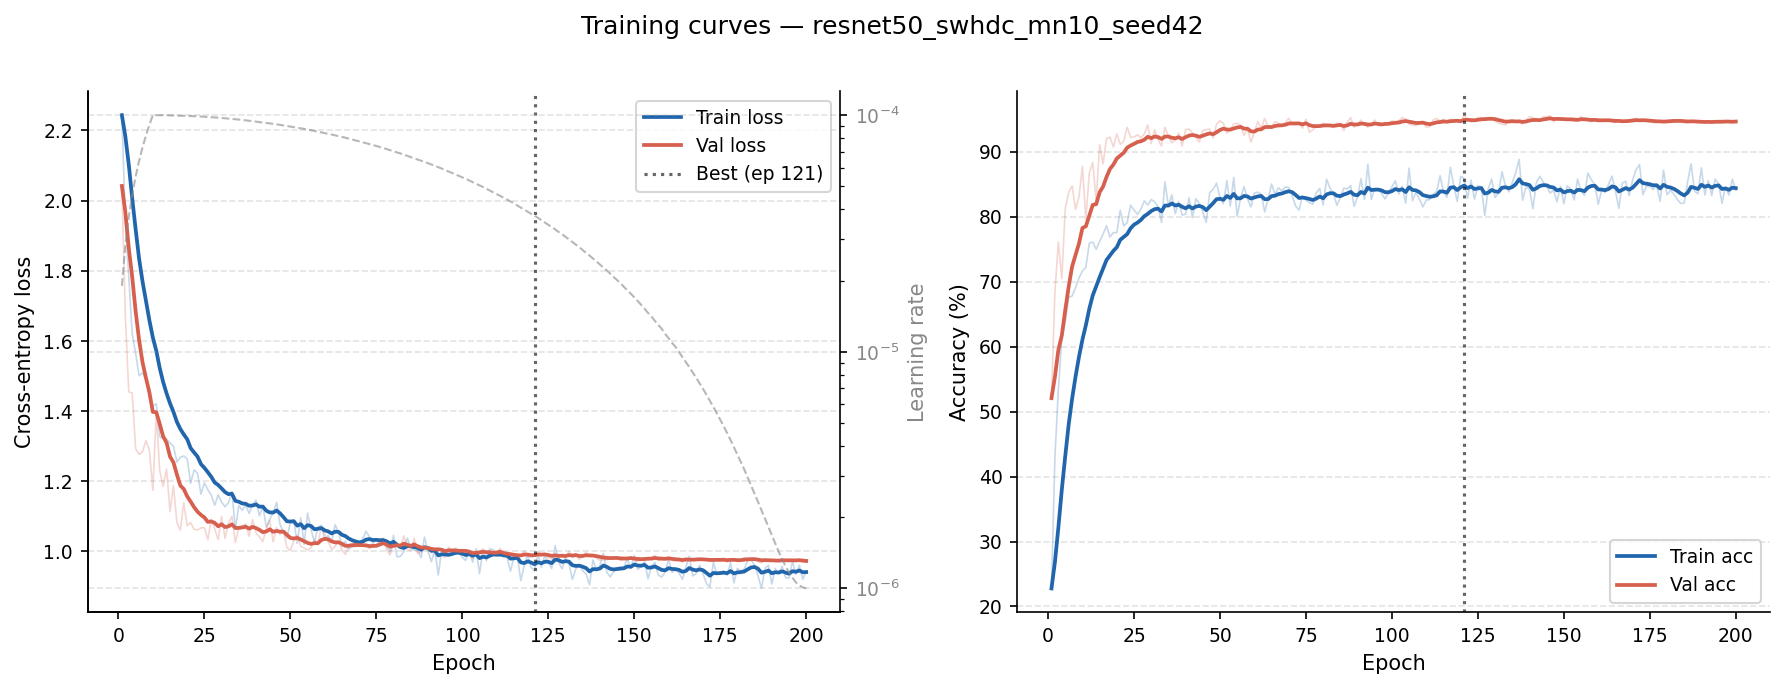

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_resnet50_swhdc_mn10_seed42.*  (best ep: 121)



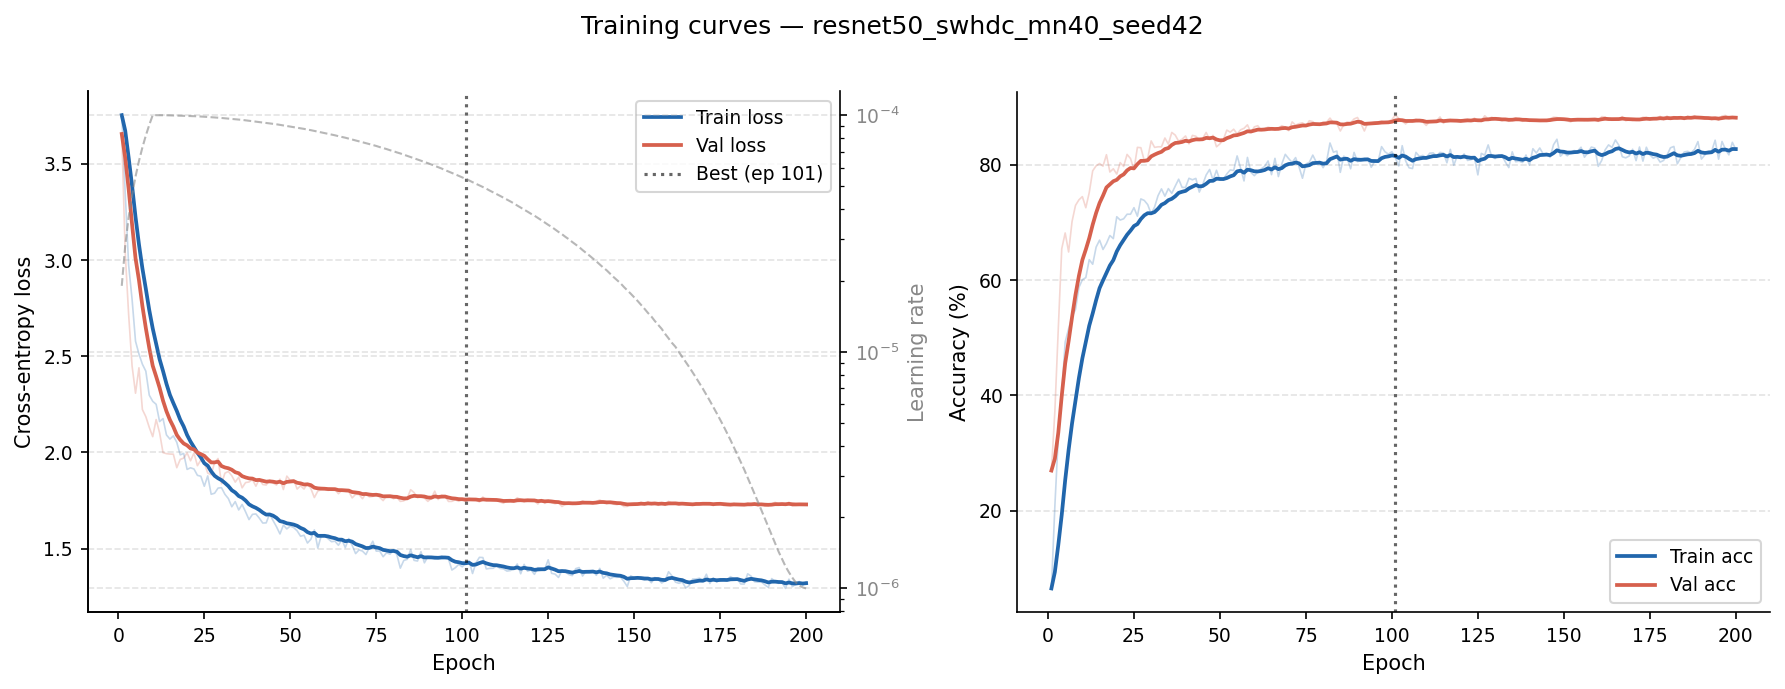

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_resnet50_swhdc_mn40_seed42.*  (best ep: 101)



In [32]:
if not runs:
    print("No runs available.")
else:
    for run_name, entry in runs.items():
        df = entry.get("metrics_df")
        if df is None:
            print(f"No metrics.csv for {run_name}, skipping.")
            continue

        best_idx   = int(df["val_acc"].idxmax())
        best_epoch = int(df.loc[best_idx, "epoch"])

        fig = plot_training_curves(
            df=df,
            run_name=run_name,
            ema_alpha=0.8,
            best_epoch=best_epoch,
            save_path=FIGURES_DIR / f"training_curves_{run_name}",
        )
        plt.show()
        print(f"Saved: {FIGURES_DIR}/training_curves_{run_name}.*  (best ep: {best_epoch})")
        print()

---
## Section 5.5: Combined Training Curves (TCC-Critical)

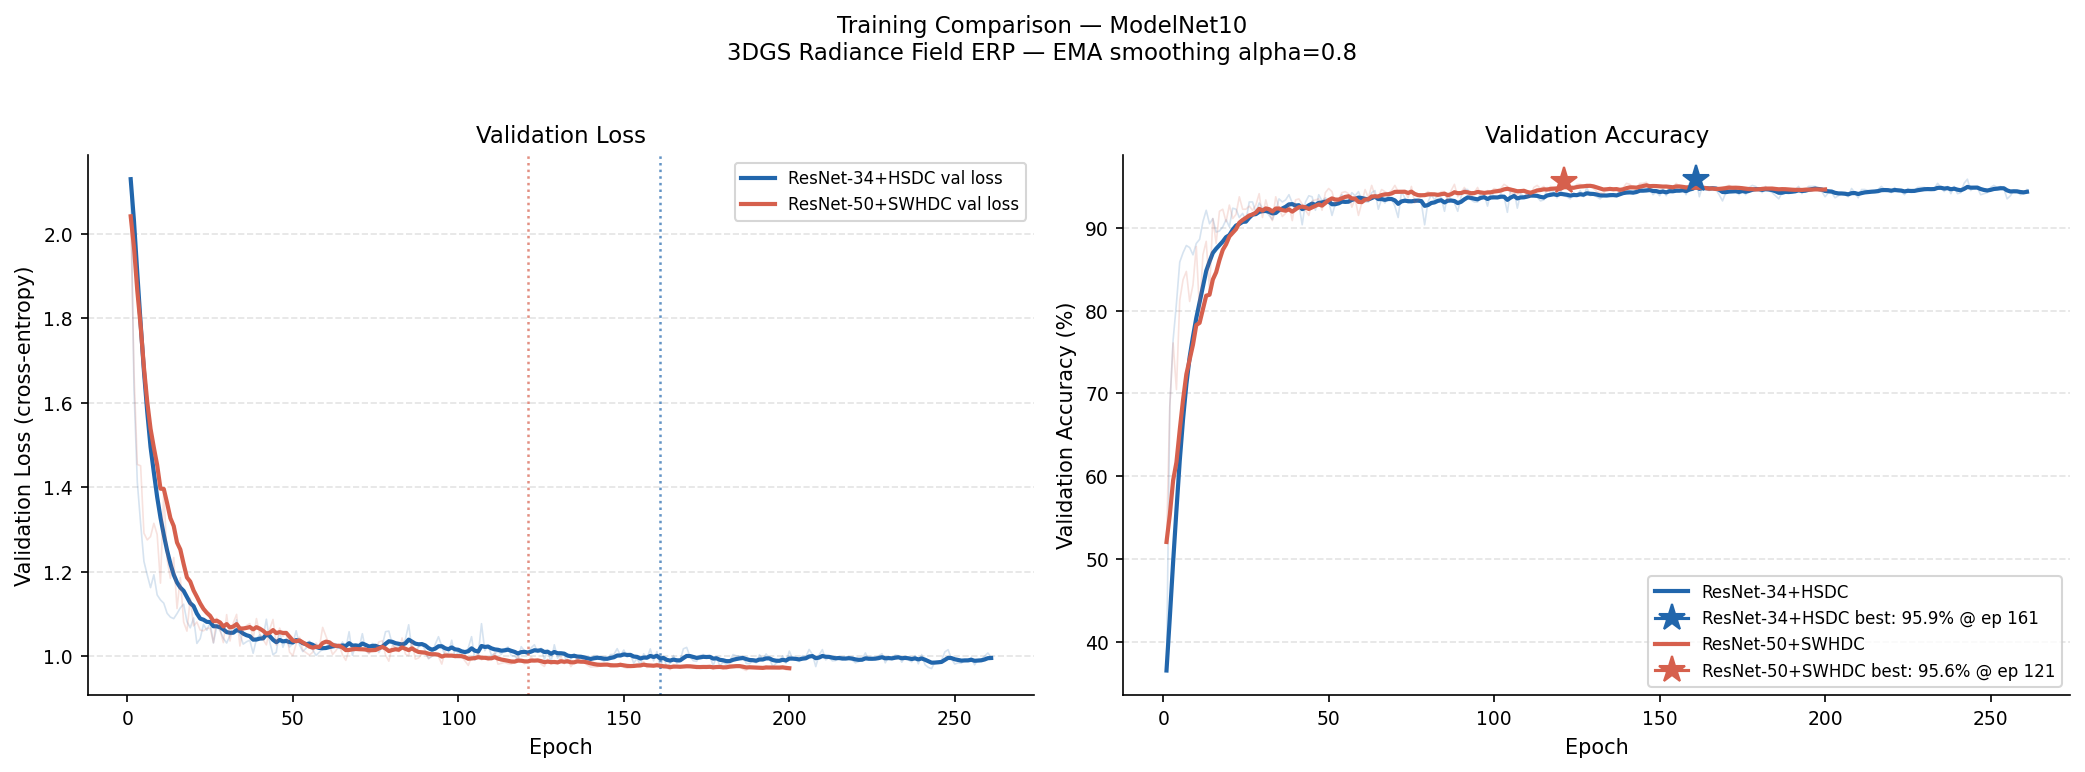

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_mn10_combined.*



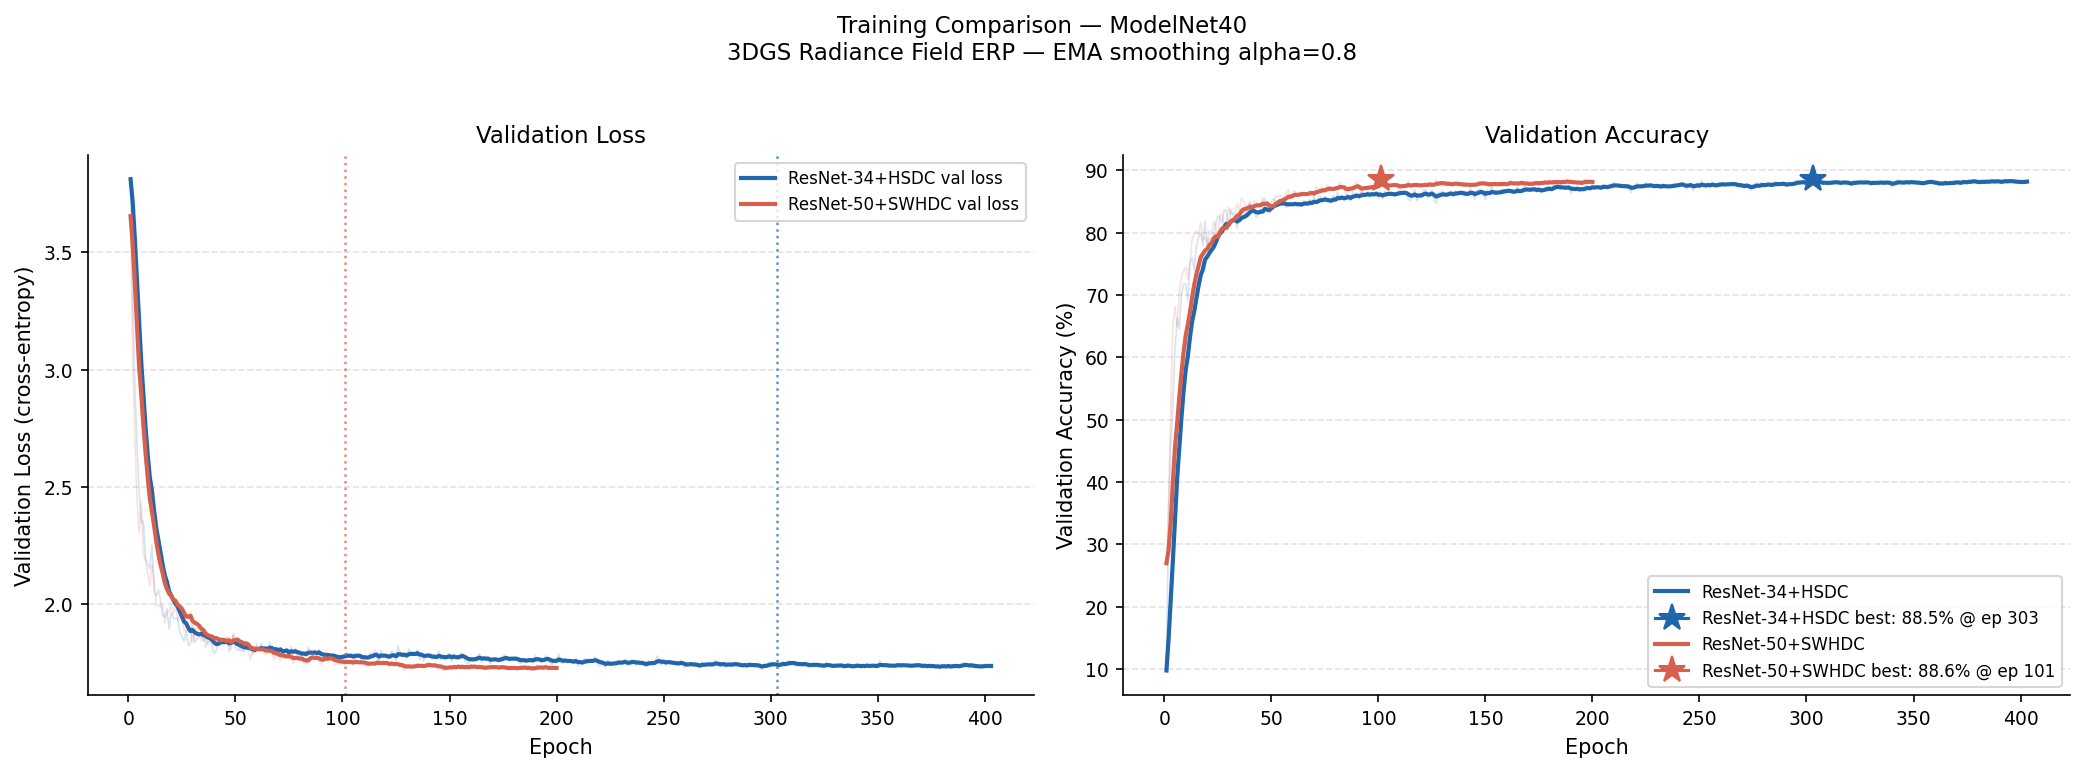

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/training_curves_mn40_combined.*


In [33]:
# Combined training curves: one figure per dataset (MN10 and MN40).
# Key TCC comparison figures showing how 3DGS RF-ERP behaves across backbones.

if not runs:
    print('No runs available.')
else:
    def _plot_combined_curves(dataset_tag: str, title_suffix: str, fname: str) -> None:
        """Plot combined val loss/acc curves for all runs matching dataset_tag."""
        run_data = [
            (name, entry['metrics_df'])
            for name, entry in runs.items()
            if dataset_tag in name.lower() and entry.get('metrics_df') is not None
        ]
        if not run_data:
            print(f'No metrics DataFrames found for {dataset_tag.upper()}.')
            return

        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f'Training Comparison \u2014 {title_suffix}\n'
            '3DGS Radiance Field ERP \u2014 EMA smoothing alpha=0.8',
            fontsize=11, y=1.02,
        )

        for run_name, df in run_data:
            color, ls, label = _run_style(run_name)
            epochs = df['epoch'].values

            val_loss_raw = df['val_loss'].values
            val_acc_raw  = df['val_acc'].values
            val_loss_s   = ema_smooth(val_loss_raw, alpha=0.8)
            val_acc_s    = ema_smooth(val_acc_raw,  alpha=0.8)

            best_idx   = int(df['val_acc'].idxmax())
            best_epoch = int(df.loc[best_idx, 'epoch'])
            best_val   = float(df.loc[best_idx, 'val_acc'])

            # Loss panel
            ax_loss.plot(epochs, val_loss_raw, color=color, alpha=0.18, linewidth=0.8)
            ax_loss.plot(epochs, val_loss_s, color=color, linestyle=ls,
                         linewidth=2.0, label=f'{label} val loss')
            ax_loss.axvline(best_epoch, color=color, linestyle=':', linewidth=1.2, alpha=0.7)

            # Accuracy panel
            ax_acc.plot(epochs, val_acc_raw, color=color, alpha=0.18, linewidth=0.8)
            ax_acc.plot(epochs, val_acc_s, color=color, linestyle=ls,
                        linewidth=2.0, label=f'{label}')
            ax_acc.plot(
                best_epoch, best_val,
                marker='*', markersize=13, color=color, zorder=5,
                label=f'{label} best: {best_val:.1f}% @ ep {best_epoch}',
            )

        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Validation Loss (cross-entropy)')
        ax_loss.set_title('Validation Loss')
        ax_loss.legend(loc='upper right', fontsize=8)

        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Validation Accuracy (%)')
        ax_acc.set_title('Validation Accuracy')
        ax_acc.legend(loc='lower right', fontsize=8)

        plt.tight_layout()
        for ext in ('png', 'pdf'):
            fig.savefig(
                FIGURES_DIR / f'{fname}.{ext}',
                dpi=300, bbox_inches='tight',
            )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/{fname}.*')

    _plot_combined_curves('mn10', 'ModelNet10', 'training_curves_mn10_combined')
    print()
    _plot_combined_curves('mn40', 'ModelNet40', 'training_curves_mn40_combined')


---
## Section 5.6: Generalization Gap Analysis

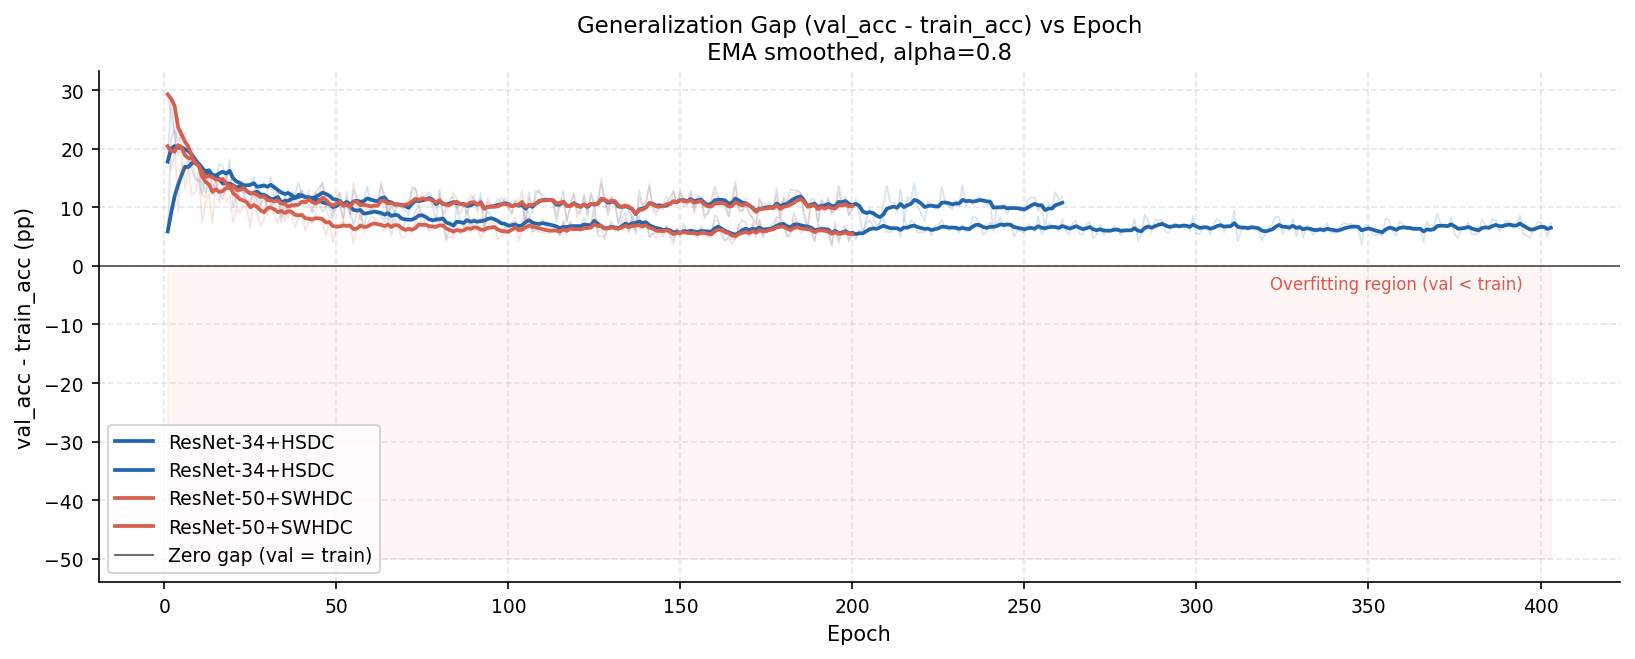

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/generalization_gap.*

Final generalization gap (last epoch):
  ResNet-34+HSDC: +11.72 pp  (train=82.9%, val=94.6%)
  ResNet-34+HSDC: +7.27 pp  (train=81.1%, val=88.4%)
  ResNet-50+SWHDC: +10.64 pp  (train=84.1%, val=94.7%)
  ResNet-50+SWHDC: +5.38 pp  (train=82.6%, val=88.0%)


In [34]:
# Generalization gap = val_acc - train_acc.
# Negative = overfitting (train >> val).
# Helps discuss model capacity and regularization in the TCC.

if not runs:
    print("No runs available.")
else:
    run_data_gap = [
        (name, entry["metrics_df"])
        for name, entry in runs.items()
        if entry.get("metrics_df") is not None
    ]

    if not run_data_gap:
        print("No metrics DataFrames found.")
    else:
        fig, ax = plt.subplots(figsize=(11, 4.5))

        all_epochs = []
        for run_name, df in run_data_gap:
            color, _, label = _run_style(run_name)
            epochs = df["epoch"].values
            all_epochs.extend(epochs.tolist())
            gap    = df["val_acc"].values - df["train_acc"].values
            gap_s  = ema_smooth(gap, alpha=0.8)
            ax.plot(epochs, gap, color=color, alpha=0.18, linewidth=0.8)
            ax.plot(epochs, gap_s, color=color, linewidth=1.8, label=label)

        x_min, x_max = min(all_epochs), max(all_epochs)
        ax.axhline(0, color="black", linewidth=0.9, linestyle="-", alpha=0.6,
                   label="Zero gap (val = train)")
        ax.fill_between(
            [x_min, x_max],
            y1=-50, y2=0,
            alpha=0.045, color=COLORS["proposed"],
        )
        ax.text(
            x_max * 0.98, -1.5, "Overfitting region (val < train)",
            ha="right", va="top", fontsize=8, color=COLORS["proposed"], alpha=0.8,
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("val_acc - train_acc (pp)")
        ax.set_title("Generalization Gap (val_acc - train_acc) vs Epoch\nEMA smoothed, alpha=0.8")
        ax.legend(loc="lower left", fontsize=9)
        ax.grid(True, axis="both", linestyle="--", alpha=0.3)

        plt.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(
                FIGURES_DIR / f"generalization_gap.{ext}",
                dpi=300, bbox_inches="tight",
            )
        plt.show()
        print(f"Saved: {FIGURES_DIR}/generalization_gap.*")

        print("\nFinal generalization gap (last epoch):")
        for run_name, df in run_data_gap:
            last = df.iloc[-1]
            gap  = last["val_acc"] - last["train_acc"]
            _, _, label = _run_style(run_name)
            print(f"  {label}: {gap:+.2f} pp  (train={last['train_acc']:.1f}%, val={last['val_acc']:.1f}%)")

---
## Section 5.7: Learning Rate Schedule

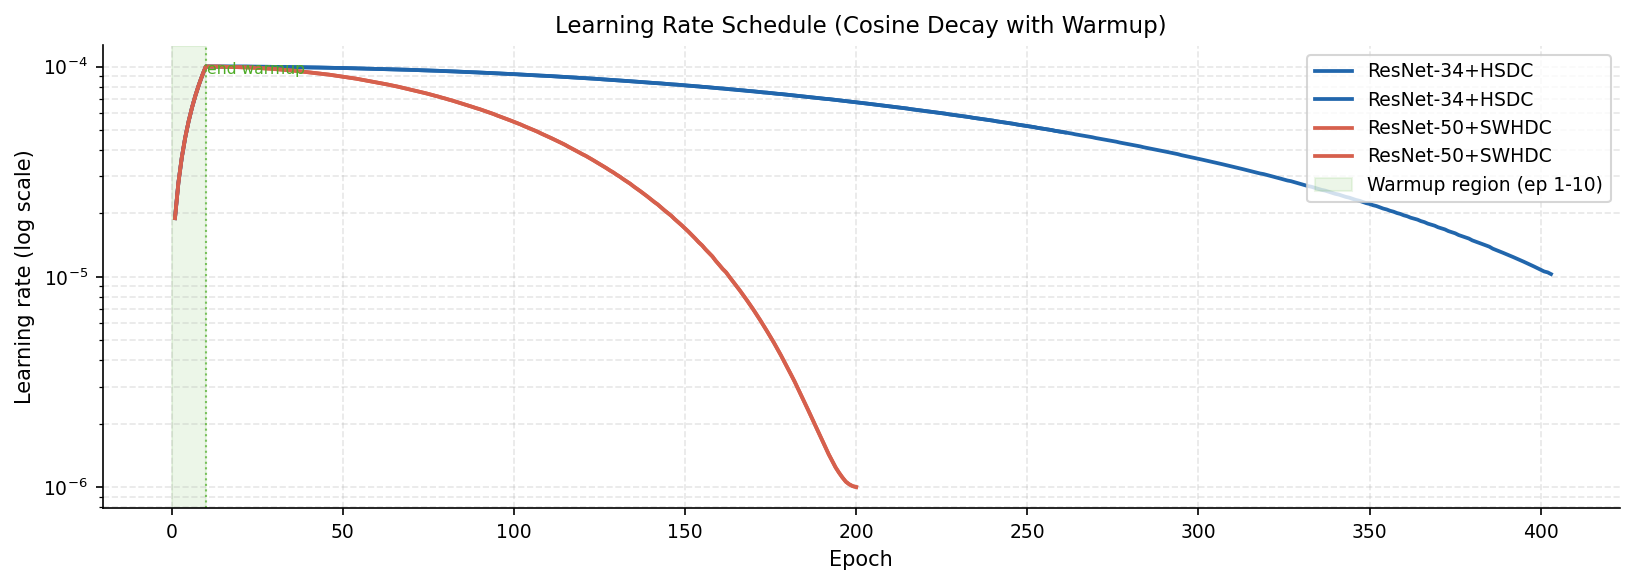

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/lr_schedule.*


In [35]:
# Plot LR vs epoch for all runs on the same axes (log scale y).
# Warmup region (first 10 epochs) is highlighted.

if not runs:
    print("No runs available.")
else:
    run_data_lr = [
        (name, entry["metrics_df"])
        for name, entry in runs.items()
        if entry.get("metrics_df") is not None
          and "lr" in (entry["metrics_df"].columns if entry.get("metrics_df") is not None else [])
    ]

    if not run_data_lr:
        print("No LR column found in metrics.csv files.")
    else:
        fig, ax = plt.subplots(figsize=(11, 4))

        warmup_end = 10  # cosine warmup for first 10 epochs

        for run_name, df in run_data_lr:
            color, _, label = _run_style(run_name)
            ax.plot(
                df["epoch"].values, df["lr"].values,
                color=color, linewidth=1.8, label=label,
            )

        ax.axvspan(0, warmup_end, alpha=0.10, color=COLORS["gap_good"],
                   label=f"Warmup region (ep 1-{warmup_end})")
        ax.axvline(warmup_end, color=COLORS["gap_good"], linestyle=":",
                   linewidth=1.0, alpha=0.7)
        ax.text(
            warmup_end + 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 1e-4,
            "end warmup", fontsize=7.5, color=COLORS["gap_good"], va="top",
        )

        ax.set_yscale("log")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Learning rate (log scale)")
        ax.set_title("Learning Rate Schedule (Cosine Decay with Warmup)")
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, axis="both", which="both", linestyle="--", alpha=0.3)

        plt.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(
                FIGURES_DIR / f"lr_schedule.{ext}",
                dpi=300, bbox_inches="tight",
            )
        plt.show()
        print(f"Saved: {FIGURES_DIR}/lr_schedule.*")

---
## Section 5.8: Training Efficiency — Epochs to Accuracy Thresholds

Epochs to first reach each val accuracy threshold (ModelNet10):



,>=70%,>=80%,>=85%,>=90%,>=92%,>=94%,>=95%
Model,,,,,,,
ResNet-34+HSDC,3,4,5,12,13,57,144
ResNet-50+SWHDC,3,5,10,15,18,29,63


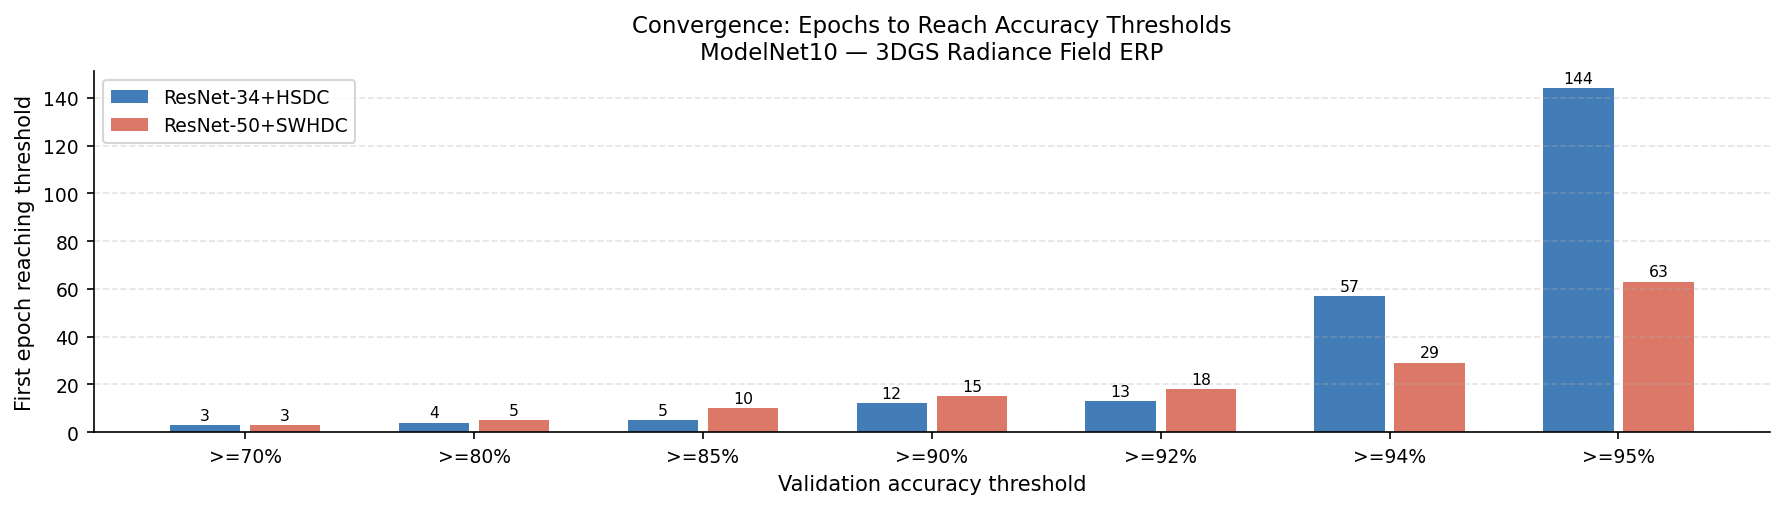

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/convergence_thresholds_mn10.*

Epochs to first reach each val accuracy threshold (ModelNet40):



,>=70%,>=80%,>=85%,>=90%,>=92%,>=94%,>=95%
Model,,,,,,,
ResNet-34+HSDC,9,19,47,N/A,N/A,N/A,N/A
ResNet-50+SWHDC,7,15,36,N/A,N/A,N/A,N/A


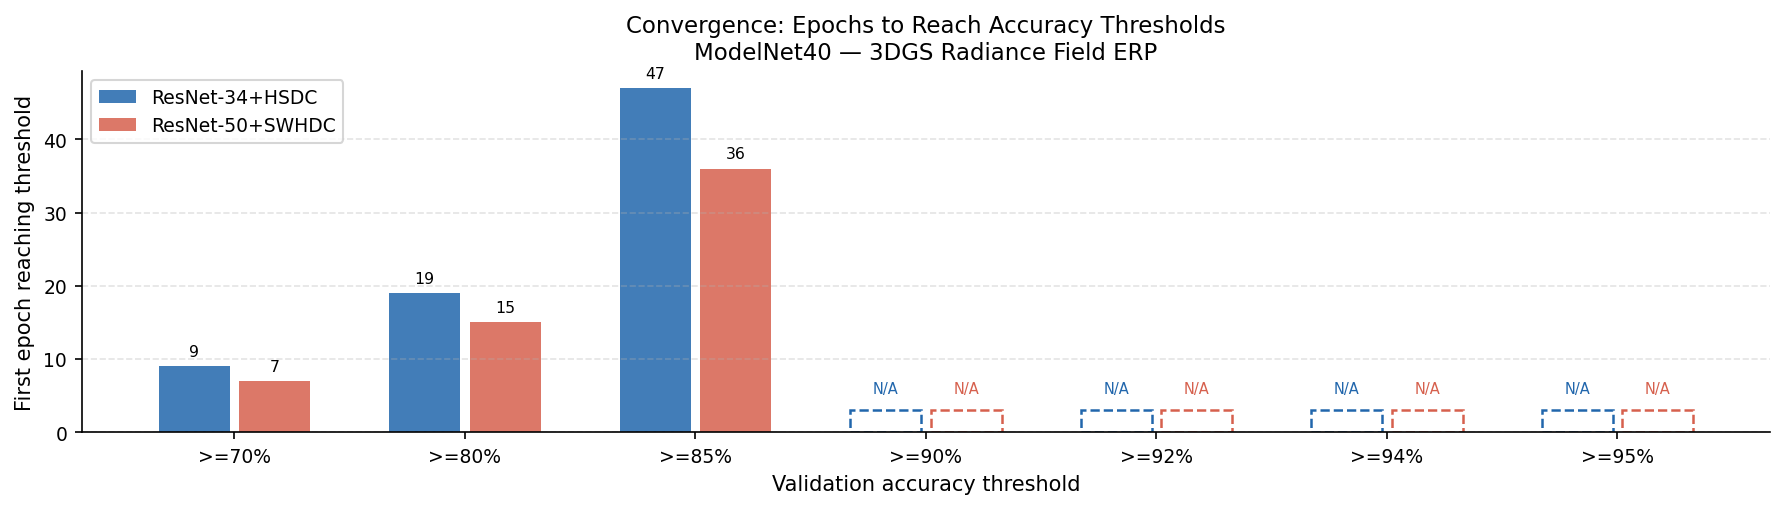

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/convergence_thresholds_mn40.*


In [36]:
# For each run: first epoch at which val_acc crosses each threshold.
# Shows convergence speed -- important for practical deployment discussions.
# Produces separate charts for MN10 and MN40.

if not runs:
    print('No runs available.')
else:
    def _plot_convergence(dataset_tag: str, title_suffix: str, fname: str) -> None:
        """Plot convergence threshold chart for runs matching dataset_tag."""
        thresholds = [70, 80, 85, 90, 92, 94, 95]
        convergence_data = {}   # label -> (run_name, {threshold -> epoch | None})

        for run_name, entry in runs.items():
            if dataset_tag not in run_name.lower():
                continue
            df = entry.get('metrics_df')
            if df is None:
                continue
            _, _, label = _run_style(run_name)
            thr_eps = {}
            for thr in thresholds:
                mask = df['val_acc'] >= thr
                if mask.any():
                    first_idx = int(mask.idxmax())
                    thr_eps[thr] = int(df.loc[first_idx, 'epoch'])
                else:
                    thr_eps[thr] = None
            convergence_data[label] = (run_name, thr_eps)

        if not convergence_data:
            print(f'No convergence data available for {dataset_tag.upper()}.')
            return

        # Print table
        print(f'Epochs to first reach each val accuracy threshold ({title_suffix}):\n')
        thr_df_rows = []
        for label, (_, thr_ep) in convergence_data.items():
            row = {'Model': label}
            for thr in thresholds:
                ep = thr_ep.get(thr)
                row[f'>={thr}%'] = ep if ep is not None else 'N/A'
            thr_df_rows.append(row)
        thr_df = pd.DataFrame(thr_df_rows).set_index('Model')
        display(thr_df)

        # Bar chart
        n_models = len(convergence_data)
        n_thrs   = len(thresholds)
        bar_h    = 0.35
        x_pos    = np.arange(n_thrs)
        offsets  = np.linspace(
            -(n_models - 1) * bar_h / 2,
             (n_models - 1) * bar_h / 2,
            n_models,
        )

        fig, ax = plt.subplots(figsize=(12, max(3.5, n_models * 1.5)))

        for idx, (label, (run_name, thr_ep)) in enumerate(convergence_data.items()):
            color, _, _ = _run_style(run_name)
            for xi, thr in enumerate(thresholds):
                ep = thr_ep.get(thr)
                if ep is not None:
                    ax.bar(
                        xi + offsets[idx], ep, width=bar_h * 0.88,
                        color=color, alpha=0.85,
                        label=label if xi == 0 else None,
                    )
                    ax.text(
                        xi + offsets[idx], ep + 1,
                        str(ep), ha='center', va='bottom', fontsize=7.5,
                    )
                else:
                    ax.bar(
                        xi + offsets[idx], 3, width=bar_h * 0.88,
                        color='none', edgecolor=color, linestyle='--', linewidth=1.2,
                    )
                    ax.text(
                        xi + offsets[idx], 5, 'N/A',
                        ha='center', va='bottom', fontsize=7, color=color,
                    )

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'>={t}%' for t in thresholds], fontsize=9)
        ax.set_xlabel('Validation accuracy threshold')
        ax.set_ylabel('First epoch reaching threshold')
        ax.set_title(
            f'Convergence: Epochs to Reach Accuracy Thresholds\n{title_suffix} \u2014 3DGS Radiance Field ERP'
        )
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, axis='y', linestyle='--', alpha=0.35)

        plt.tight_layout()
        for ext in ('png', 'pdf'):
            fig.savefig(
                FIGURES_DIR / f'{fname}.{ext}',
                dpi=300, bbox_inches='tight',
            )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/{fname}.*')

    _plot_convergence('mn10', 'ModelNet10', 'convergence_thresholds_mn10')
    print()
    _plot_convergence('mn40', 'ModelNet40', 'convergence_thresholds_mn40')


---
## Section 6: Confusion Matrices

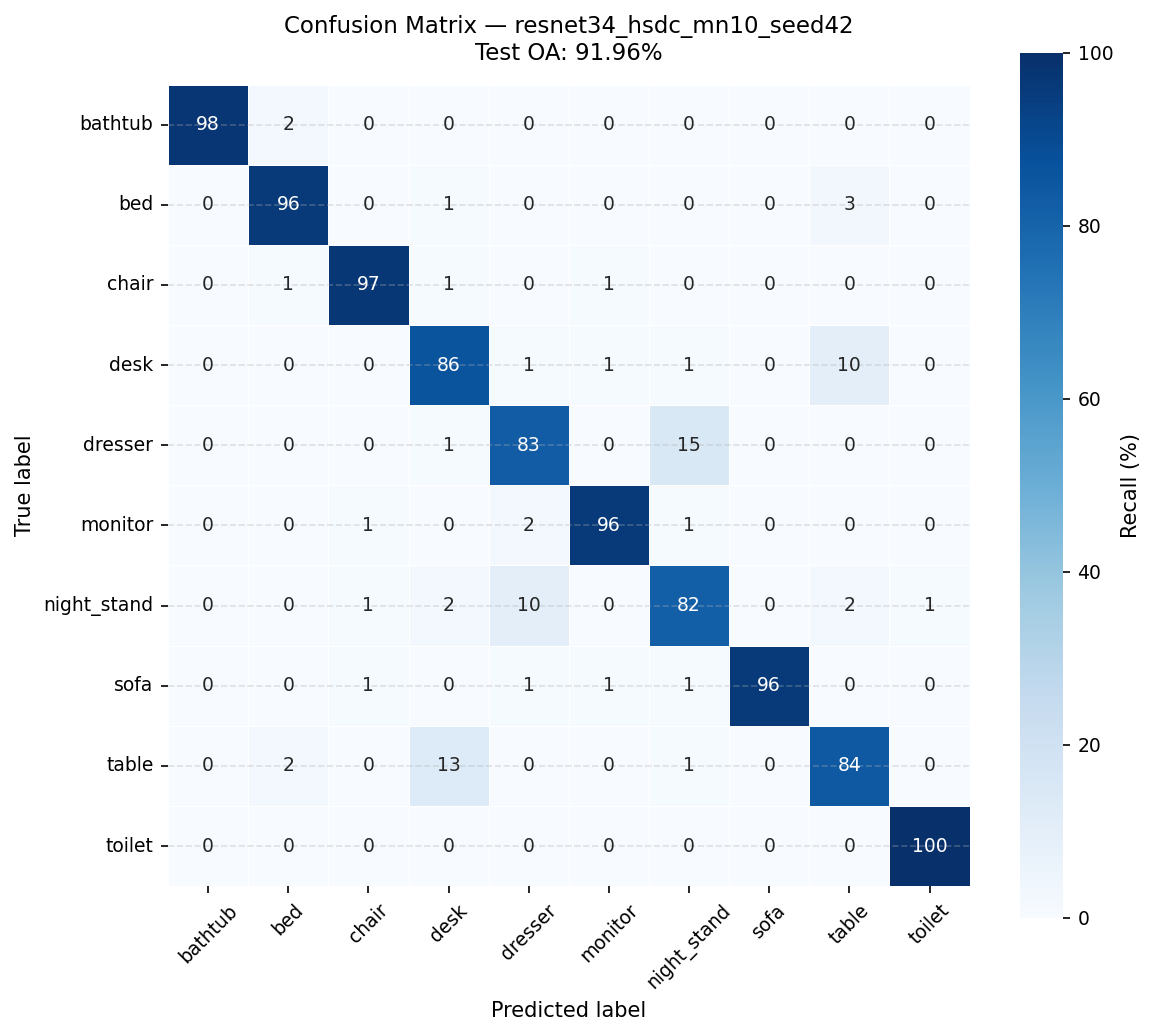

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/confusion_matrix_resnet34_hsdc_mn10_seed42.*



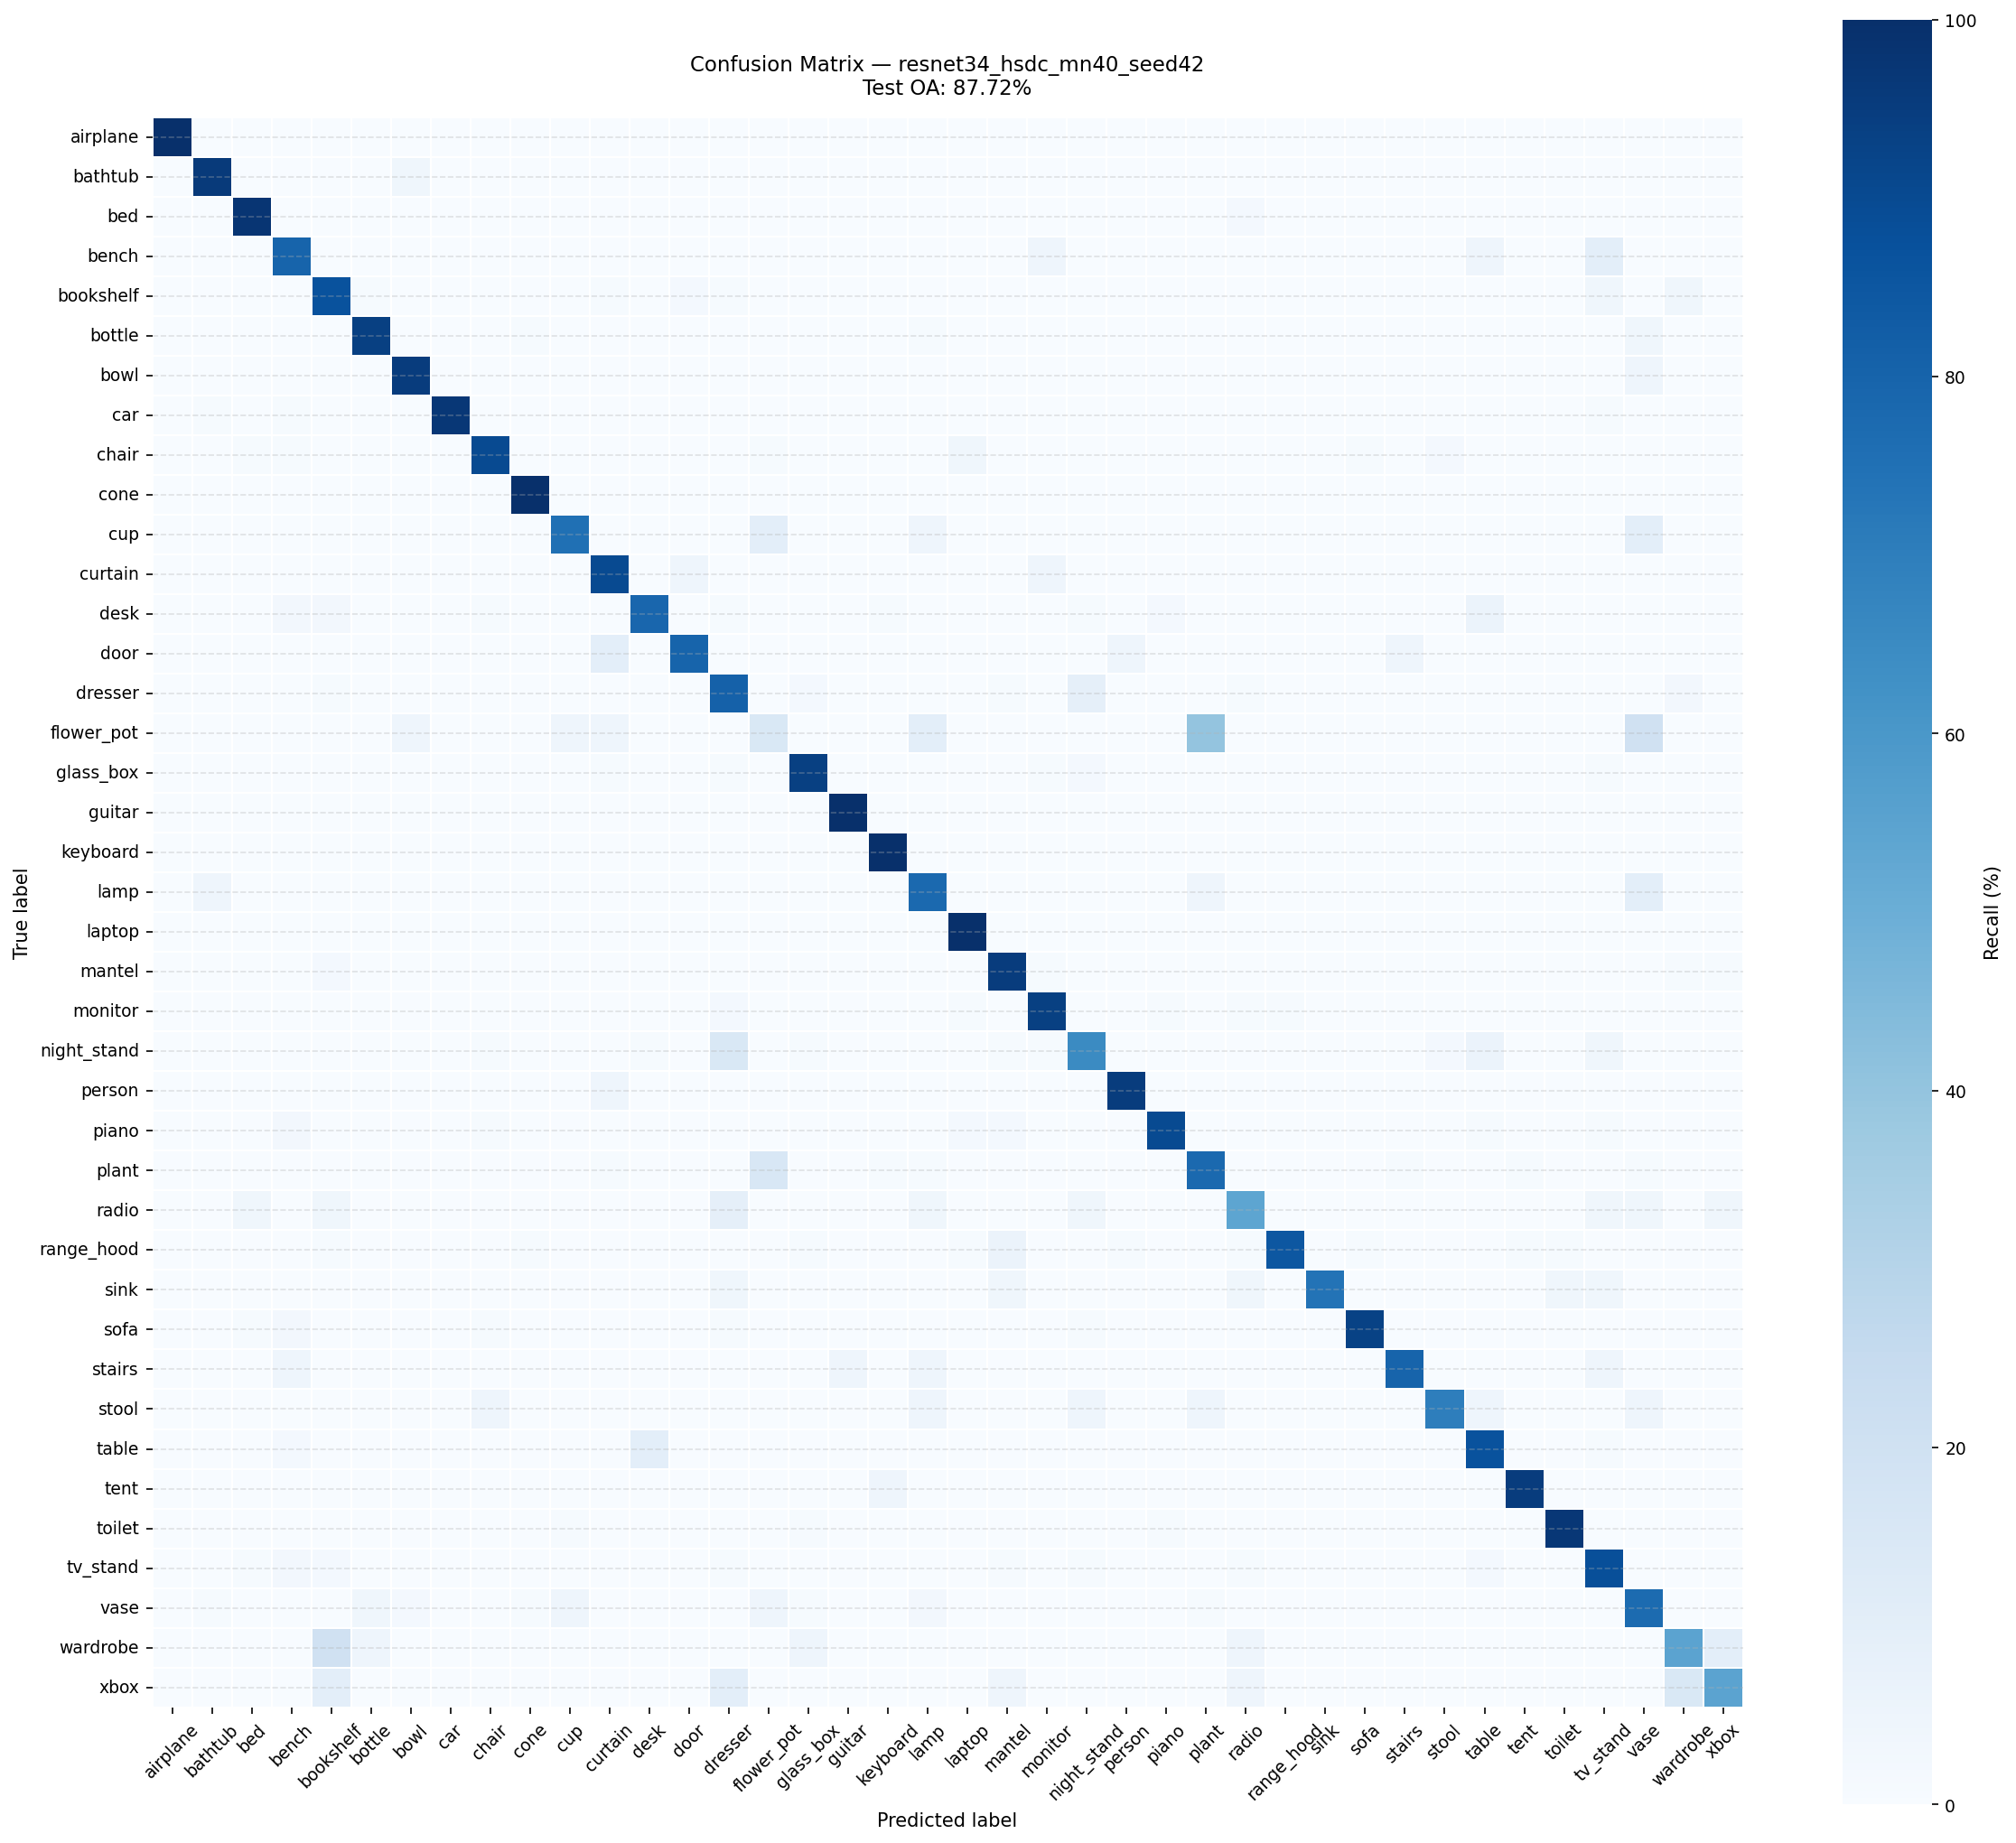

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/confusion_matrix_resnet34_hsdc_mn40_seed42.*



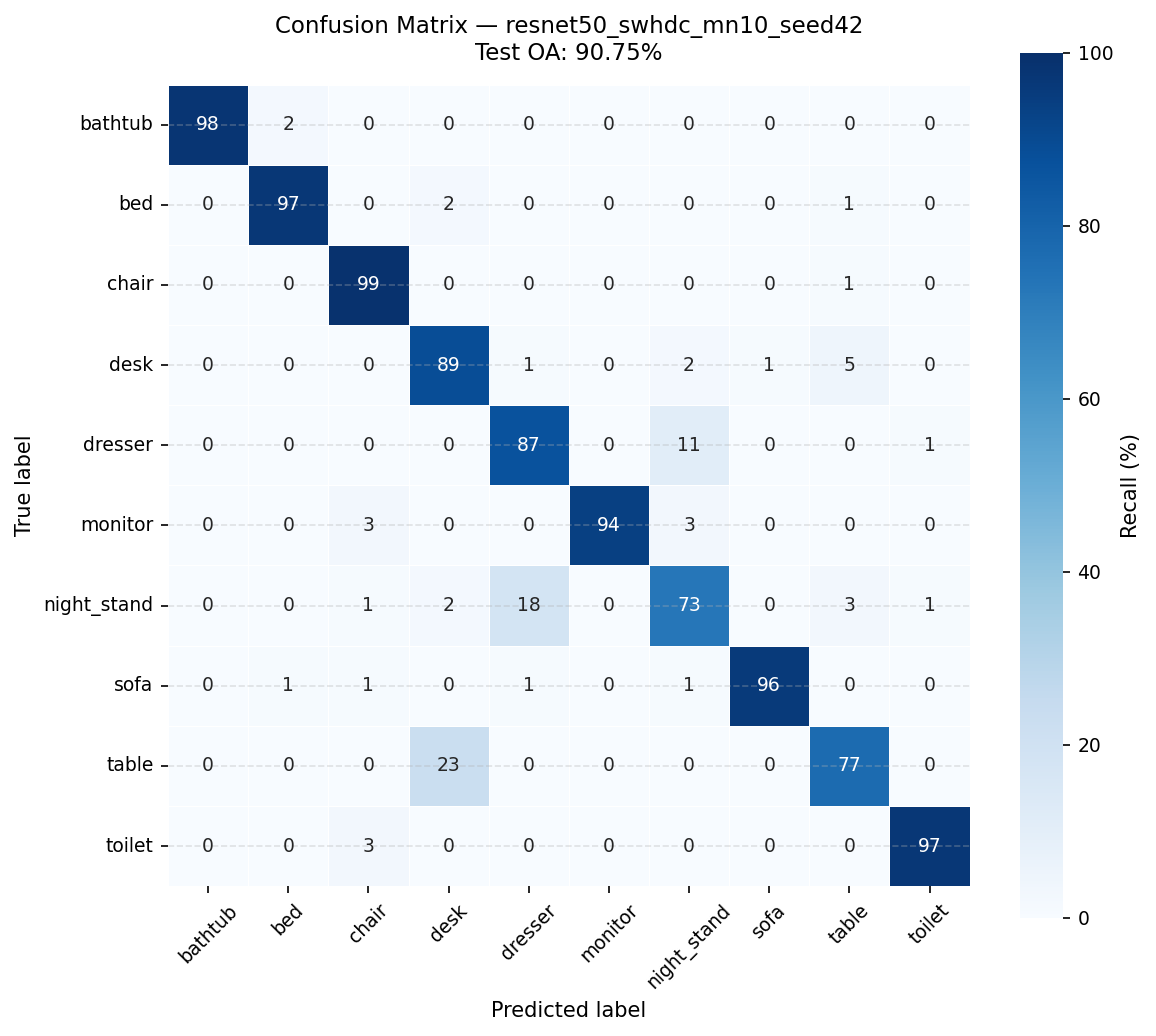

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/confusion_matrix_resnet50_swhdc_mn10_seed42.*



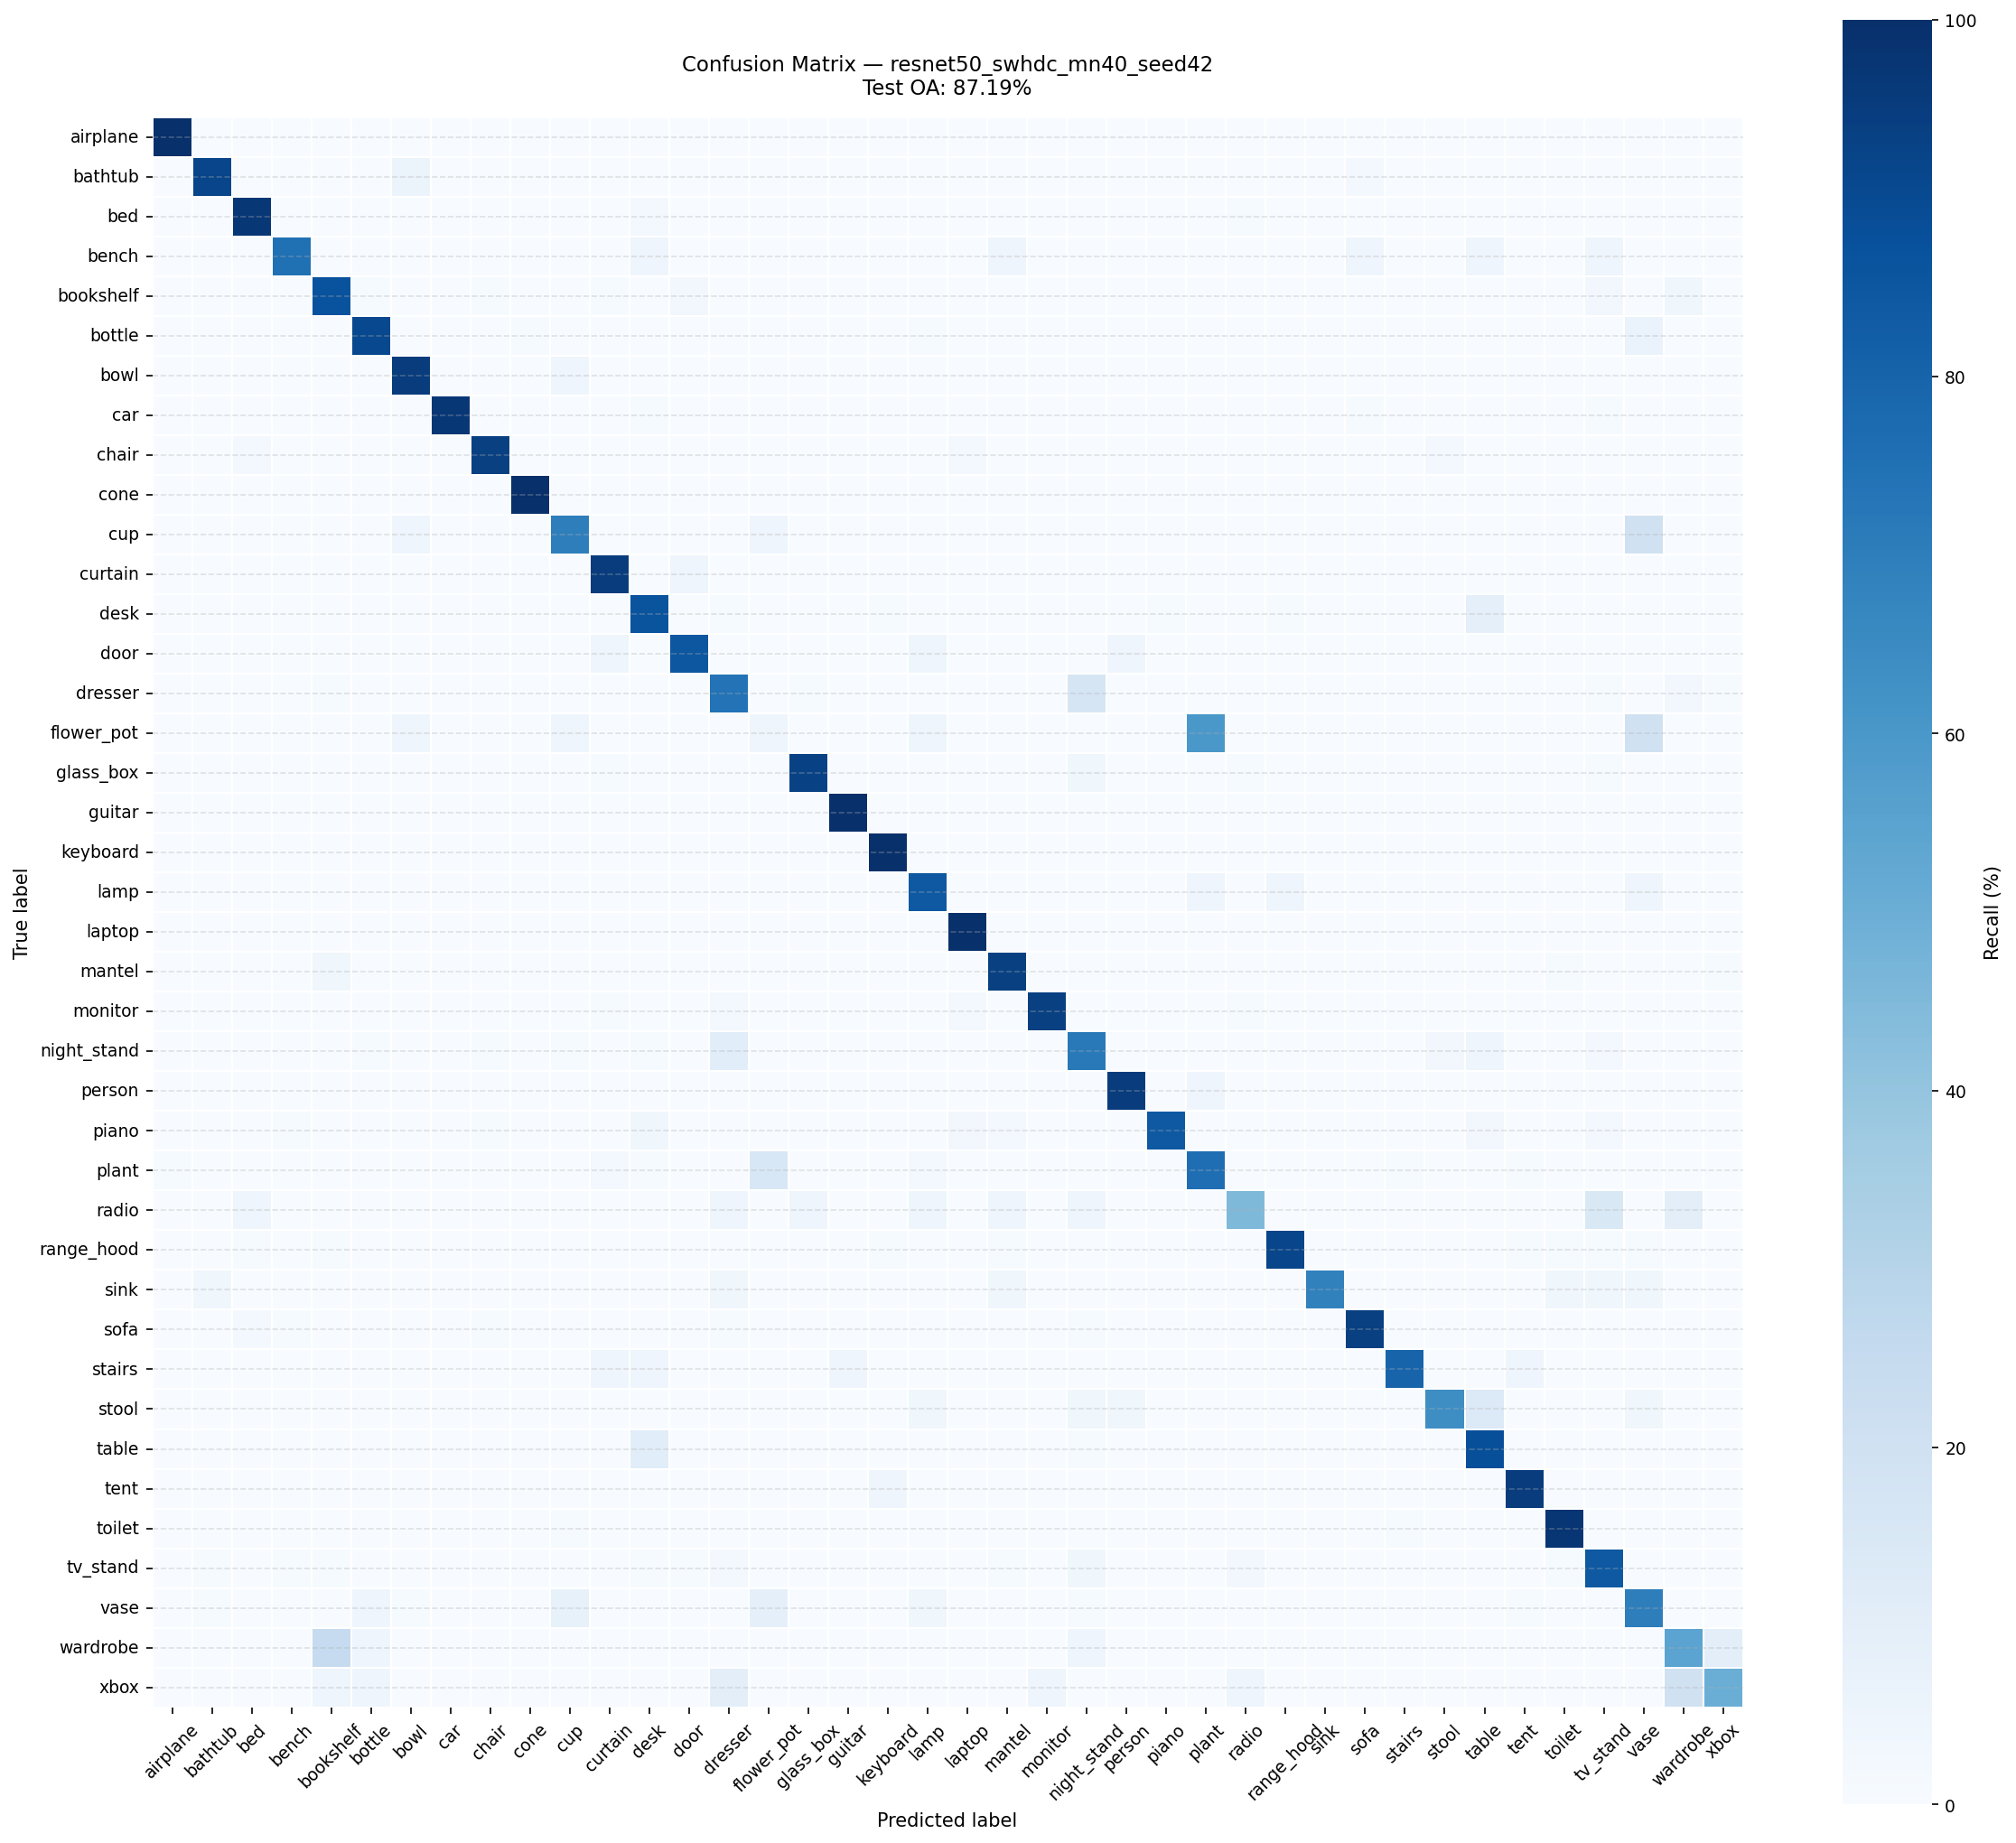

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/confusion_matrix_resnet50_swhdc_mn40_seed42.*



In [37]:
if not runs:
    print("No runs available.")
else:
    for run_name, entry in runs.items():
        y_true = entry.get("y_true")
        y_pred = entry.get("y_pred")

        if y_true is None or y_pred is None:
            # Fall back to confusion_matrix.npy if it exists
            cm_path = entry["run_dir"] / "confusion_matrix.npy"
            if cm_path.exists():
                cm_raw = np.load(str(cm_path))
                test   = entry.get("test") or {}
                n_cls  = int(test.get("num_classes", cm_raw.shape[0]))
                class_names = class_names_for(n_cls)
                # Normalize if raw counts (values > 1)
                if cm_raw.max() > 1:
                    row_sums = cm_raw.sum(axis=1, keepdims=True).clip(min=1)
                    cm = cm_raw / row_sums
                else:
                    cm = cm_raw
                print(f"Loaded confusion_matrix.npy for {run_name}.")
            else:
                print(f"No predictions or confusion_matrix.npy for {run_name}. Skipping.")
                continue
        else:
            test        = entry.get("test") or {}
            n_cls       = int(test.get("num_classes", int(y_true.max()) + 1))
            class_names = class_names_for(n_cls)
            cm = compute_confusion_matrix(y_true, y_pred, n_cls, normalize="true")

        test   = entry.get("test") or {}
        oa_pct = _oa_to_pct(test.get("oa"))
        title  = f"Confusion Matrix — {run_name}\nTest OA: {oa_pct:.2f}%"

        fig = plot_confusion_matrix(
            cm=cm,
            class_names=class_names,
            title=title,
            save_path=FIGURES_DIR / f"confusion_matrix_{run_name}",
        )
        plt.show()
        print(f"Saved: {FIGURES_DIR}/confusion_matrix_{run_name}.*")
        print()

---
## Section 7: Per-Class Accuracy

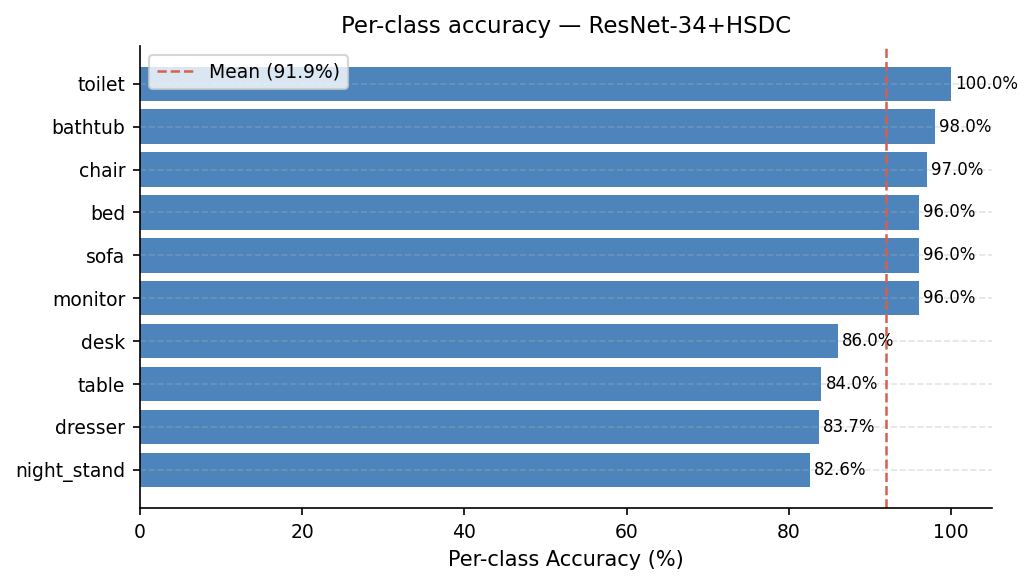

Per-class accuracy — ResNet-34+HSDC:
  bathtub        :  98.0% ###################
  bed            :  96.0% ###################
  chair          :  97.0% ###################
  desk           :  86.0% #################
  dresser        :  83.7% ################
  monitor        :  96.0% ###################
  night_stand    :  82.6% ################
  sofa           :  96.0% ###################
  table          :  84.0% ################
  toilet         : 100.0% ####################



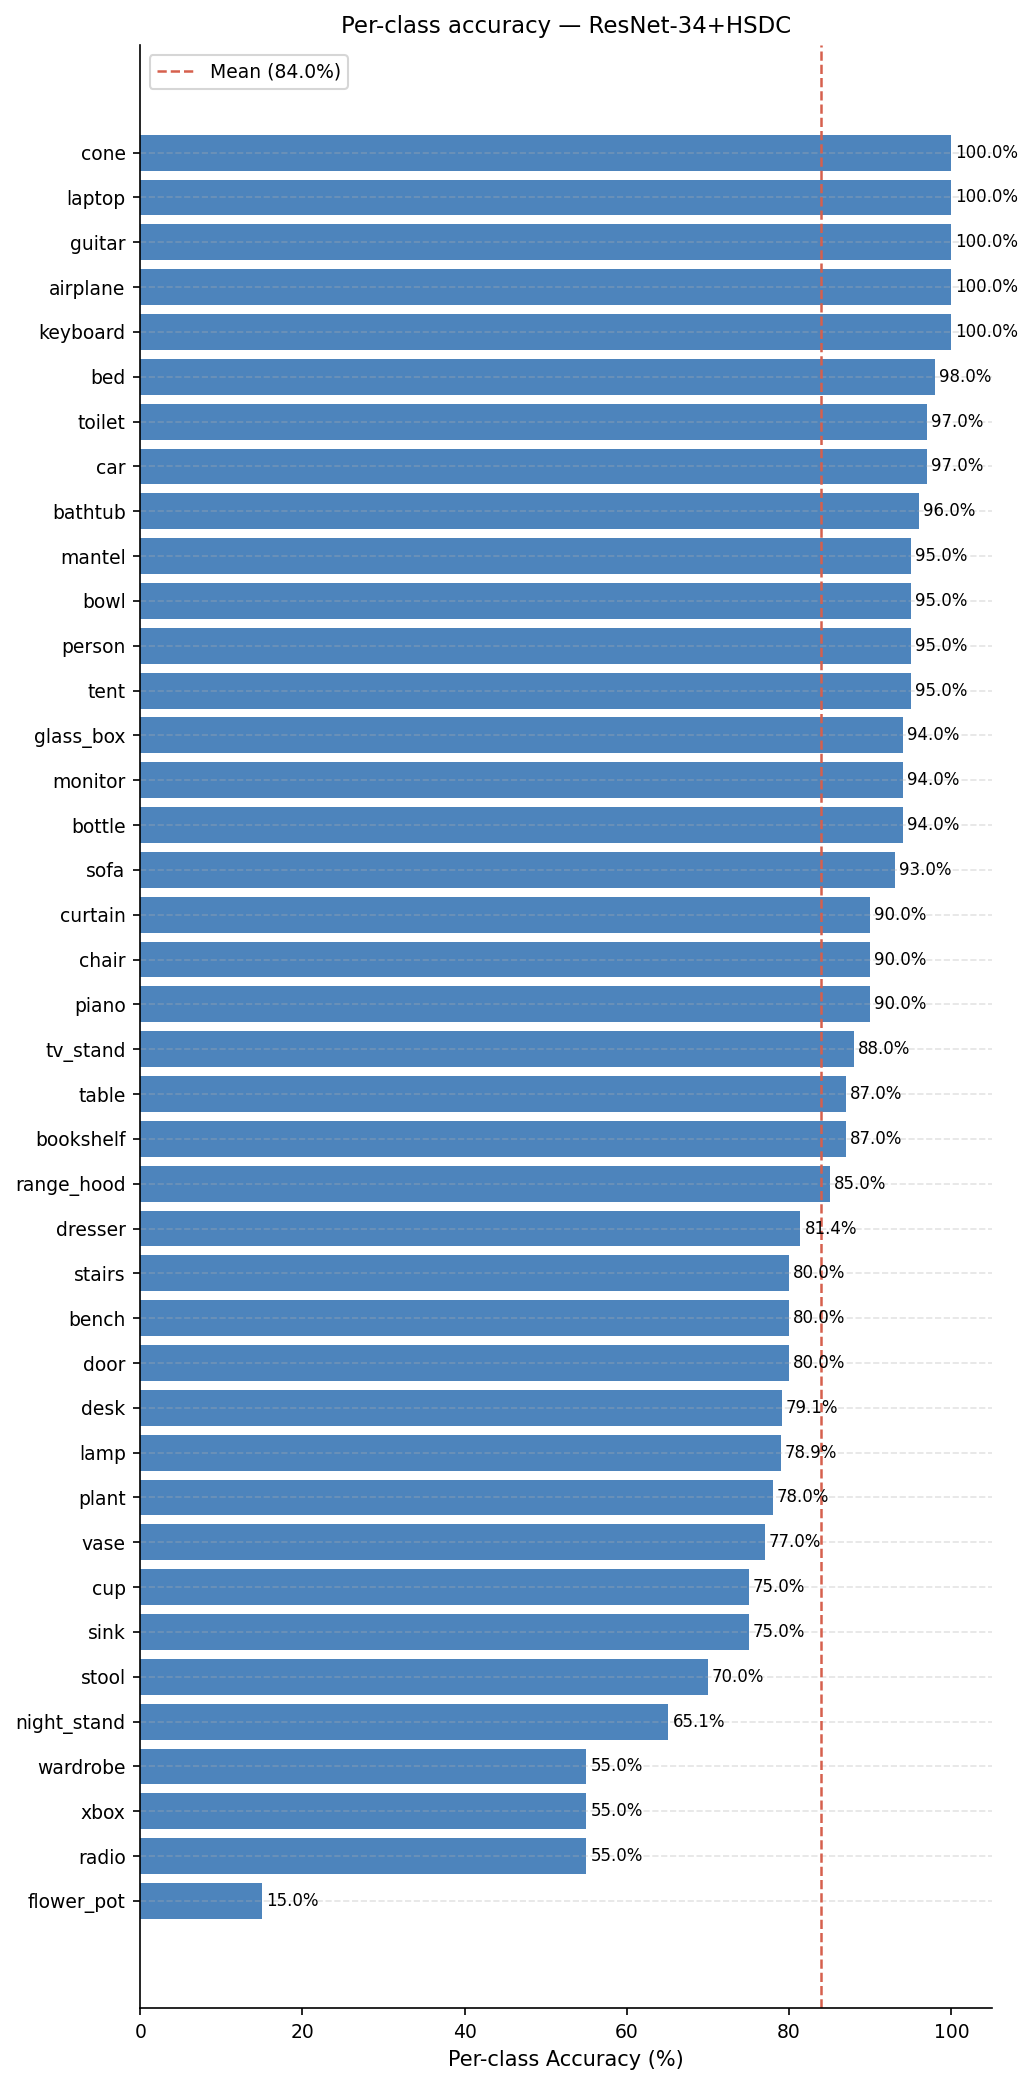

Per-class accuracy — ResNet-34+HSDC:
  airplane       : 100.0% ####################
  bathtub        :  96.0% ###################
  bed            :  98.0% ###################
  bench          :  80.0% ################
  bookshelf      :  87.0% #################
  bottle         :  94.0% ##################
  bowl           :  95.0% ###################
  car            :  97.0% ###################
  chair          :  90.0% ##################
  cone           : 100.0% ####################
  cup            :  75.0% ###############
  curtain        :  90.0% ##################
  desk           :  79.1% ###############
  door           :  80.0% ################
  dresser        :  81.4% ################
  flower_pot     :  15.0% ###
  glass_box      :  94.0% ##################
  guitar         : 100.0% ####################
  keyboard       : 100.0% ####################
  lamp           :  78.9% ###############
  laptop         : 100.0% ####################
  mantel         :  95.0% #########

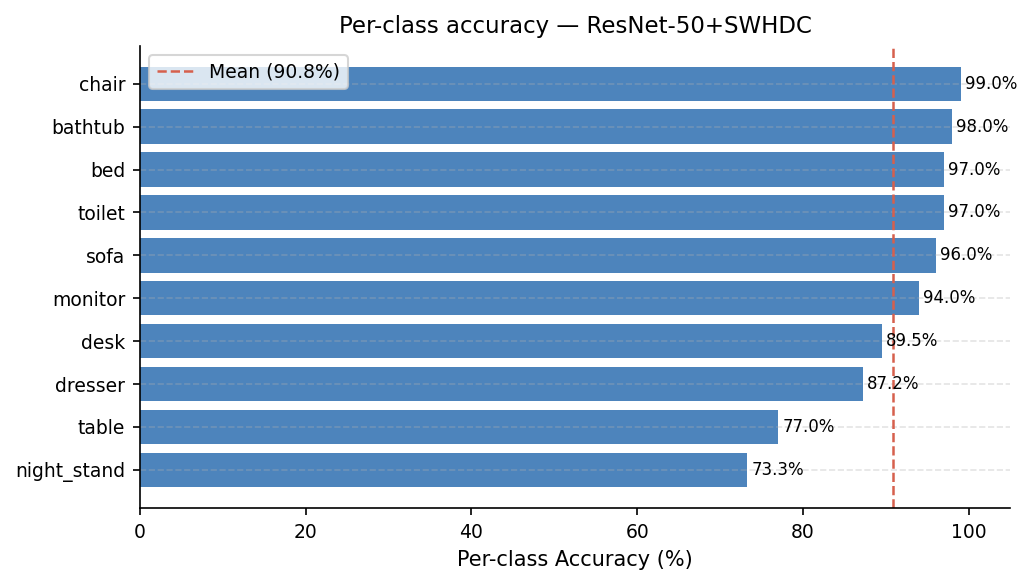

Per-class accuracy — ResNet-50+SWHDC:
  bathtub        :  98.0% ###################
  bed            :  97.0% ###################
  chair          :  99.0% ###################
  desk           :  89.5% #################
  dresser        :  87.2% #################
  monitor        :  94.0% ##################
  night_stand    :  73.3% ##############
  sofa           :  96.0% ###################
  table          :  77.0% ###############
  toilet         :  97.0% ###################



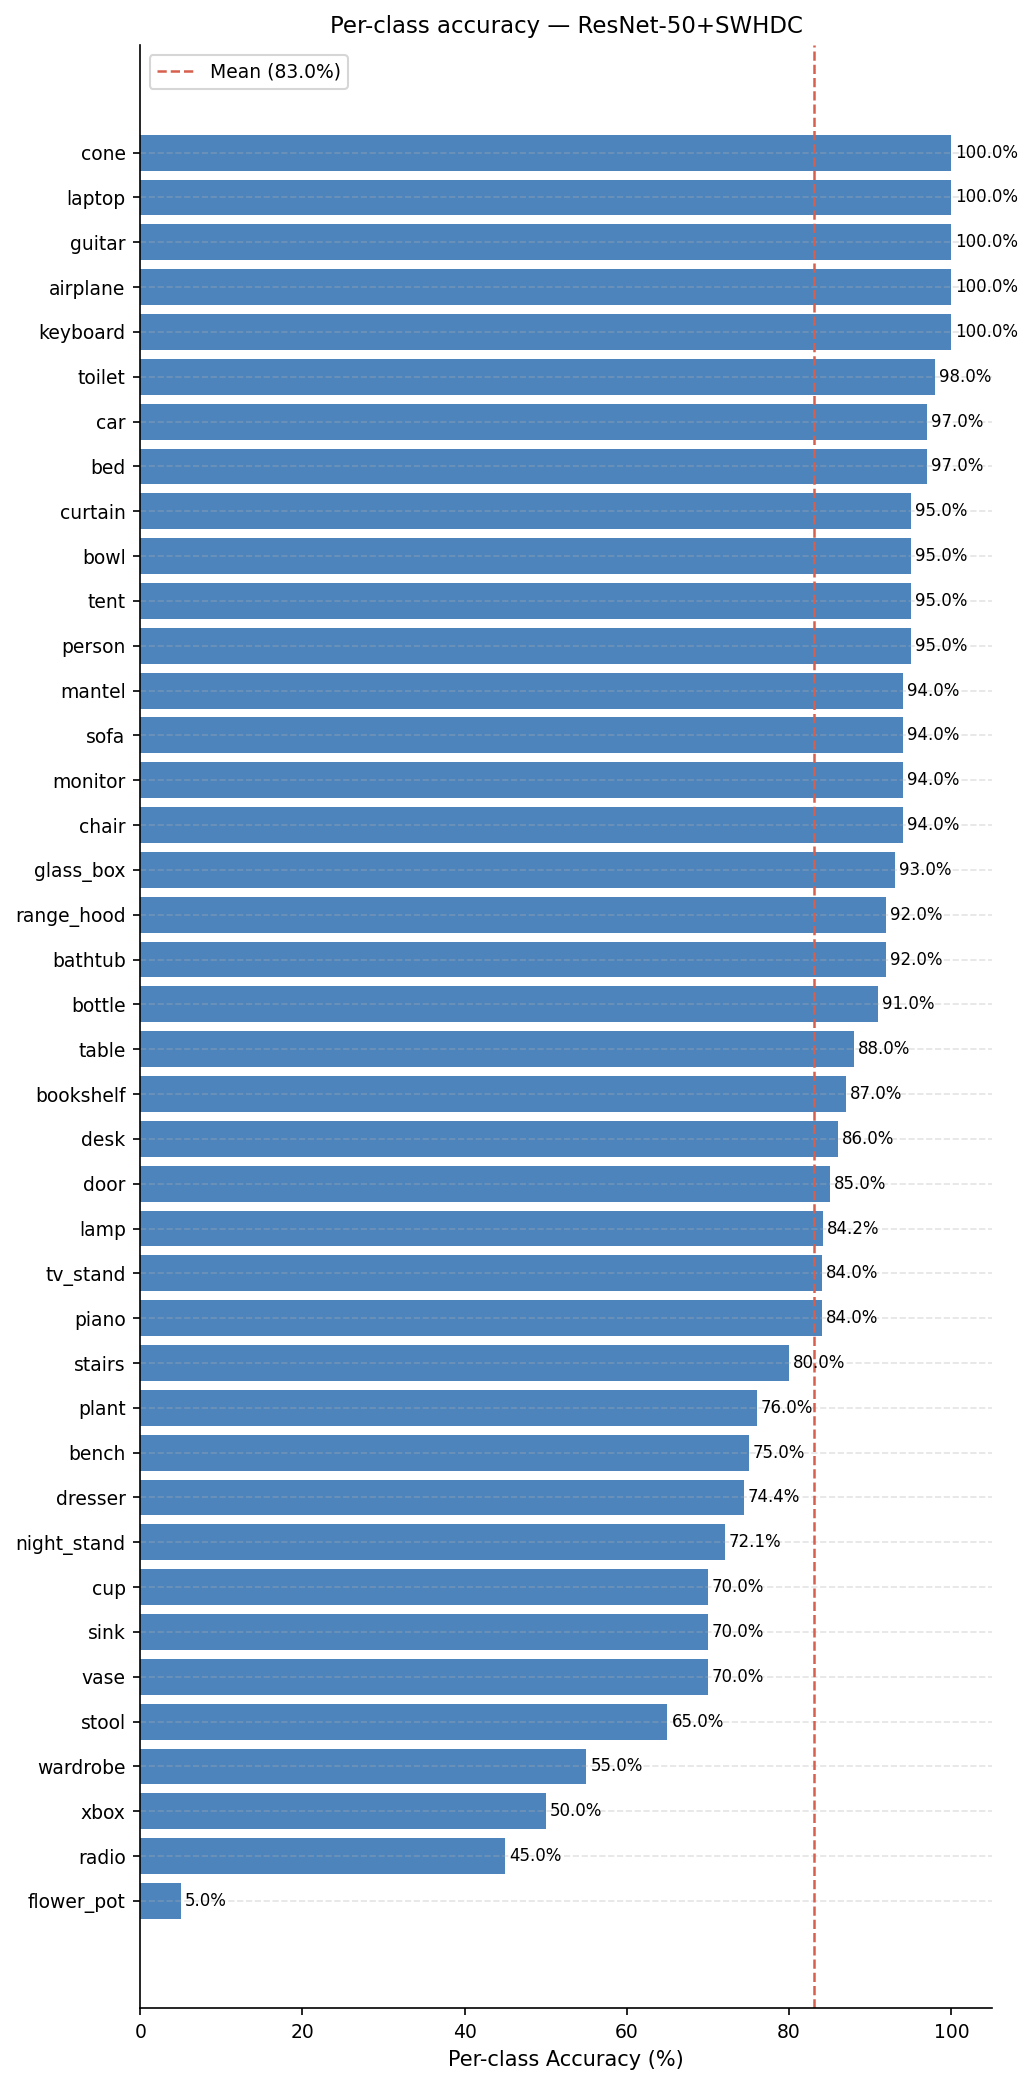

Per-class accuracy — ResNet-50+SWHDC:
  airplane       : 100.0% ####################
  bathtub        :  92.0% ##################
  bed            :  97.0% ###################
  bench          :  75.0% ###############
  bookshelf      :  87.0% #################
  bottle         :  91.0% ##################
  bowl           :  95.0% ###################
  car            :  97.0% ###################
  chair          :  94.0% ##################
  cone           : 100.0% ####################
  cup            :  70.0% ##############
  curtain        :  95.0% ###################
  desk           :  86.0% #################
  door           :  85.0% #################
  dresser        :  74.4% ##############
  flower_pot     :   5.0% #
  glass_box      :  93.0% ##################
  guitar         : 100.0% ####################
  keyboard       : 100.0% ####################
  lamp           :  84.2% ################
  laptop         : 100.0% ####################
  mantel         :  94.0% ##########

In [38]:
if not runs:
    print("No runs available.")
else:
    for run_name, entry in runs.items():
        y_true = entry.get("y_true")
        y_pred = entry.get("y_pred")
        if y_true is None or y_pred is None:
            print(f"No predictions for {run_name}. Skipping per-class accuracy.")
            continue

        test        = entry.get("test") or {}
        n_cls       = int(test.get("num_classes", int(y_true.max()) + 1))
        class_names = class_names_for(n_cls)
        per_class   = compute_per_class_accuracy(y_true, y_pred, n_cls)
        _, _, label = _run_style(run_name)

        fig = plot_per_class_accuracy(
            per_class_acc=per_class,
            class_names=class_names,
            run_label=label,
            save_path=FIGURES_DIR / f"per_class_acc_{run_name}",
        )
        plt.show()
        print(f"Per-class accuracy — {label}:")
        for cls, acc in zip(class_names, per_class):
            bar = "#" * int(acc * 20)
            print(f"  {cls:15s}: {acc*100:5.1f}% {bar}")
        print()

---
## Section 7.5: Per-Class Accuracy Comparison (TCC-Critical)

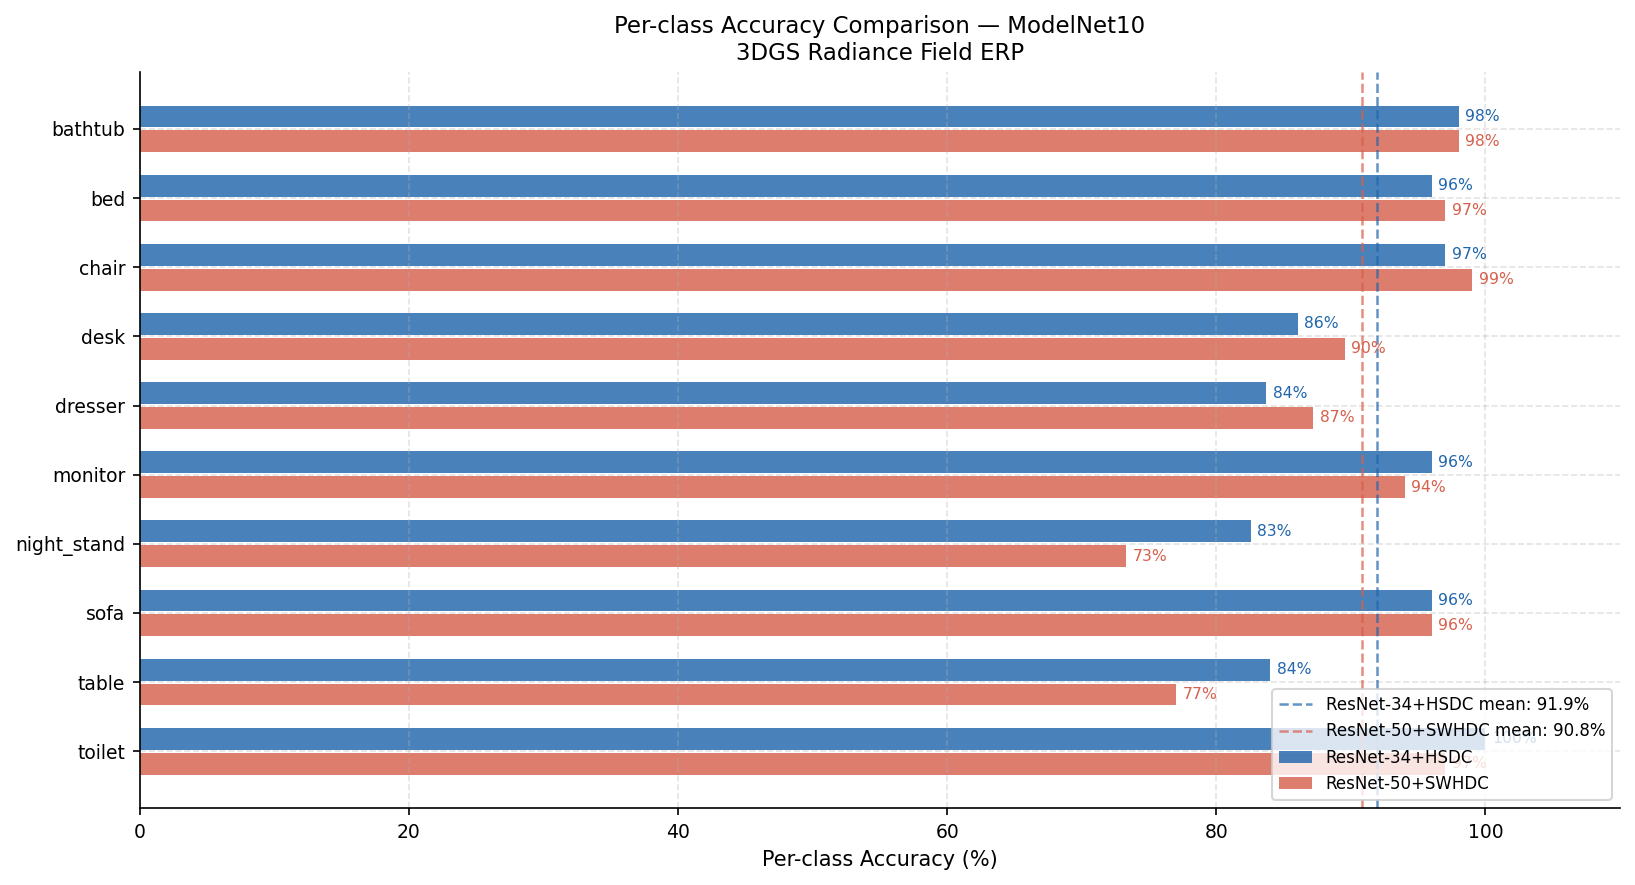

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/per_class_comparison_mn10.*

Class-level comparison (ResNet-34+HSDC - ResNet-50+SWHDC):
  night_stand    : +9.3 pp  -> ResNet-34+HSDC wins
  table          : +7.0 pp  -> ResNet-34+HSDC wins
  desk           : -3.5 pp  -> ResNet-50+SWHDC wins
  dresser        : -3.5 pp  -> ResNet-50+SWHDC wins
  toilet         : +3.0 pp  -> ResNet-34+HSDC wins
  chair          : -2.0 pp  -> ResNet-50+SWHDC wins
  monitor        : +2.0 pp  -> ResNet-34+HSDC wins
  bed            : -1.0 pp  -> ResNet-50+SWHDC wins
  bathtub        : +0.0 pp  -> tie wins
  sofa           : +0.0 pp  -> tie wins



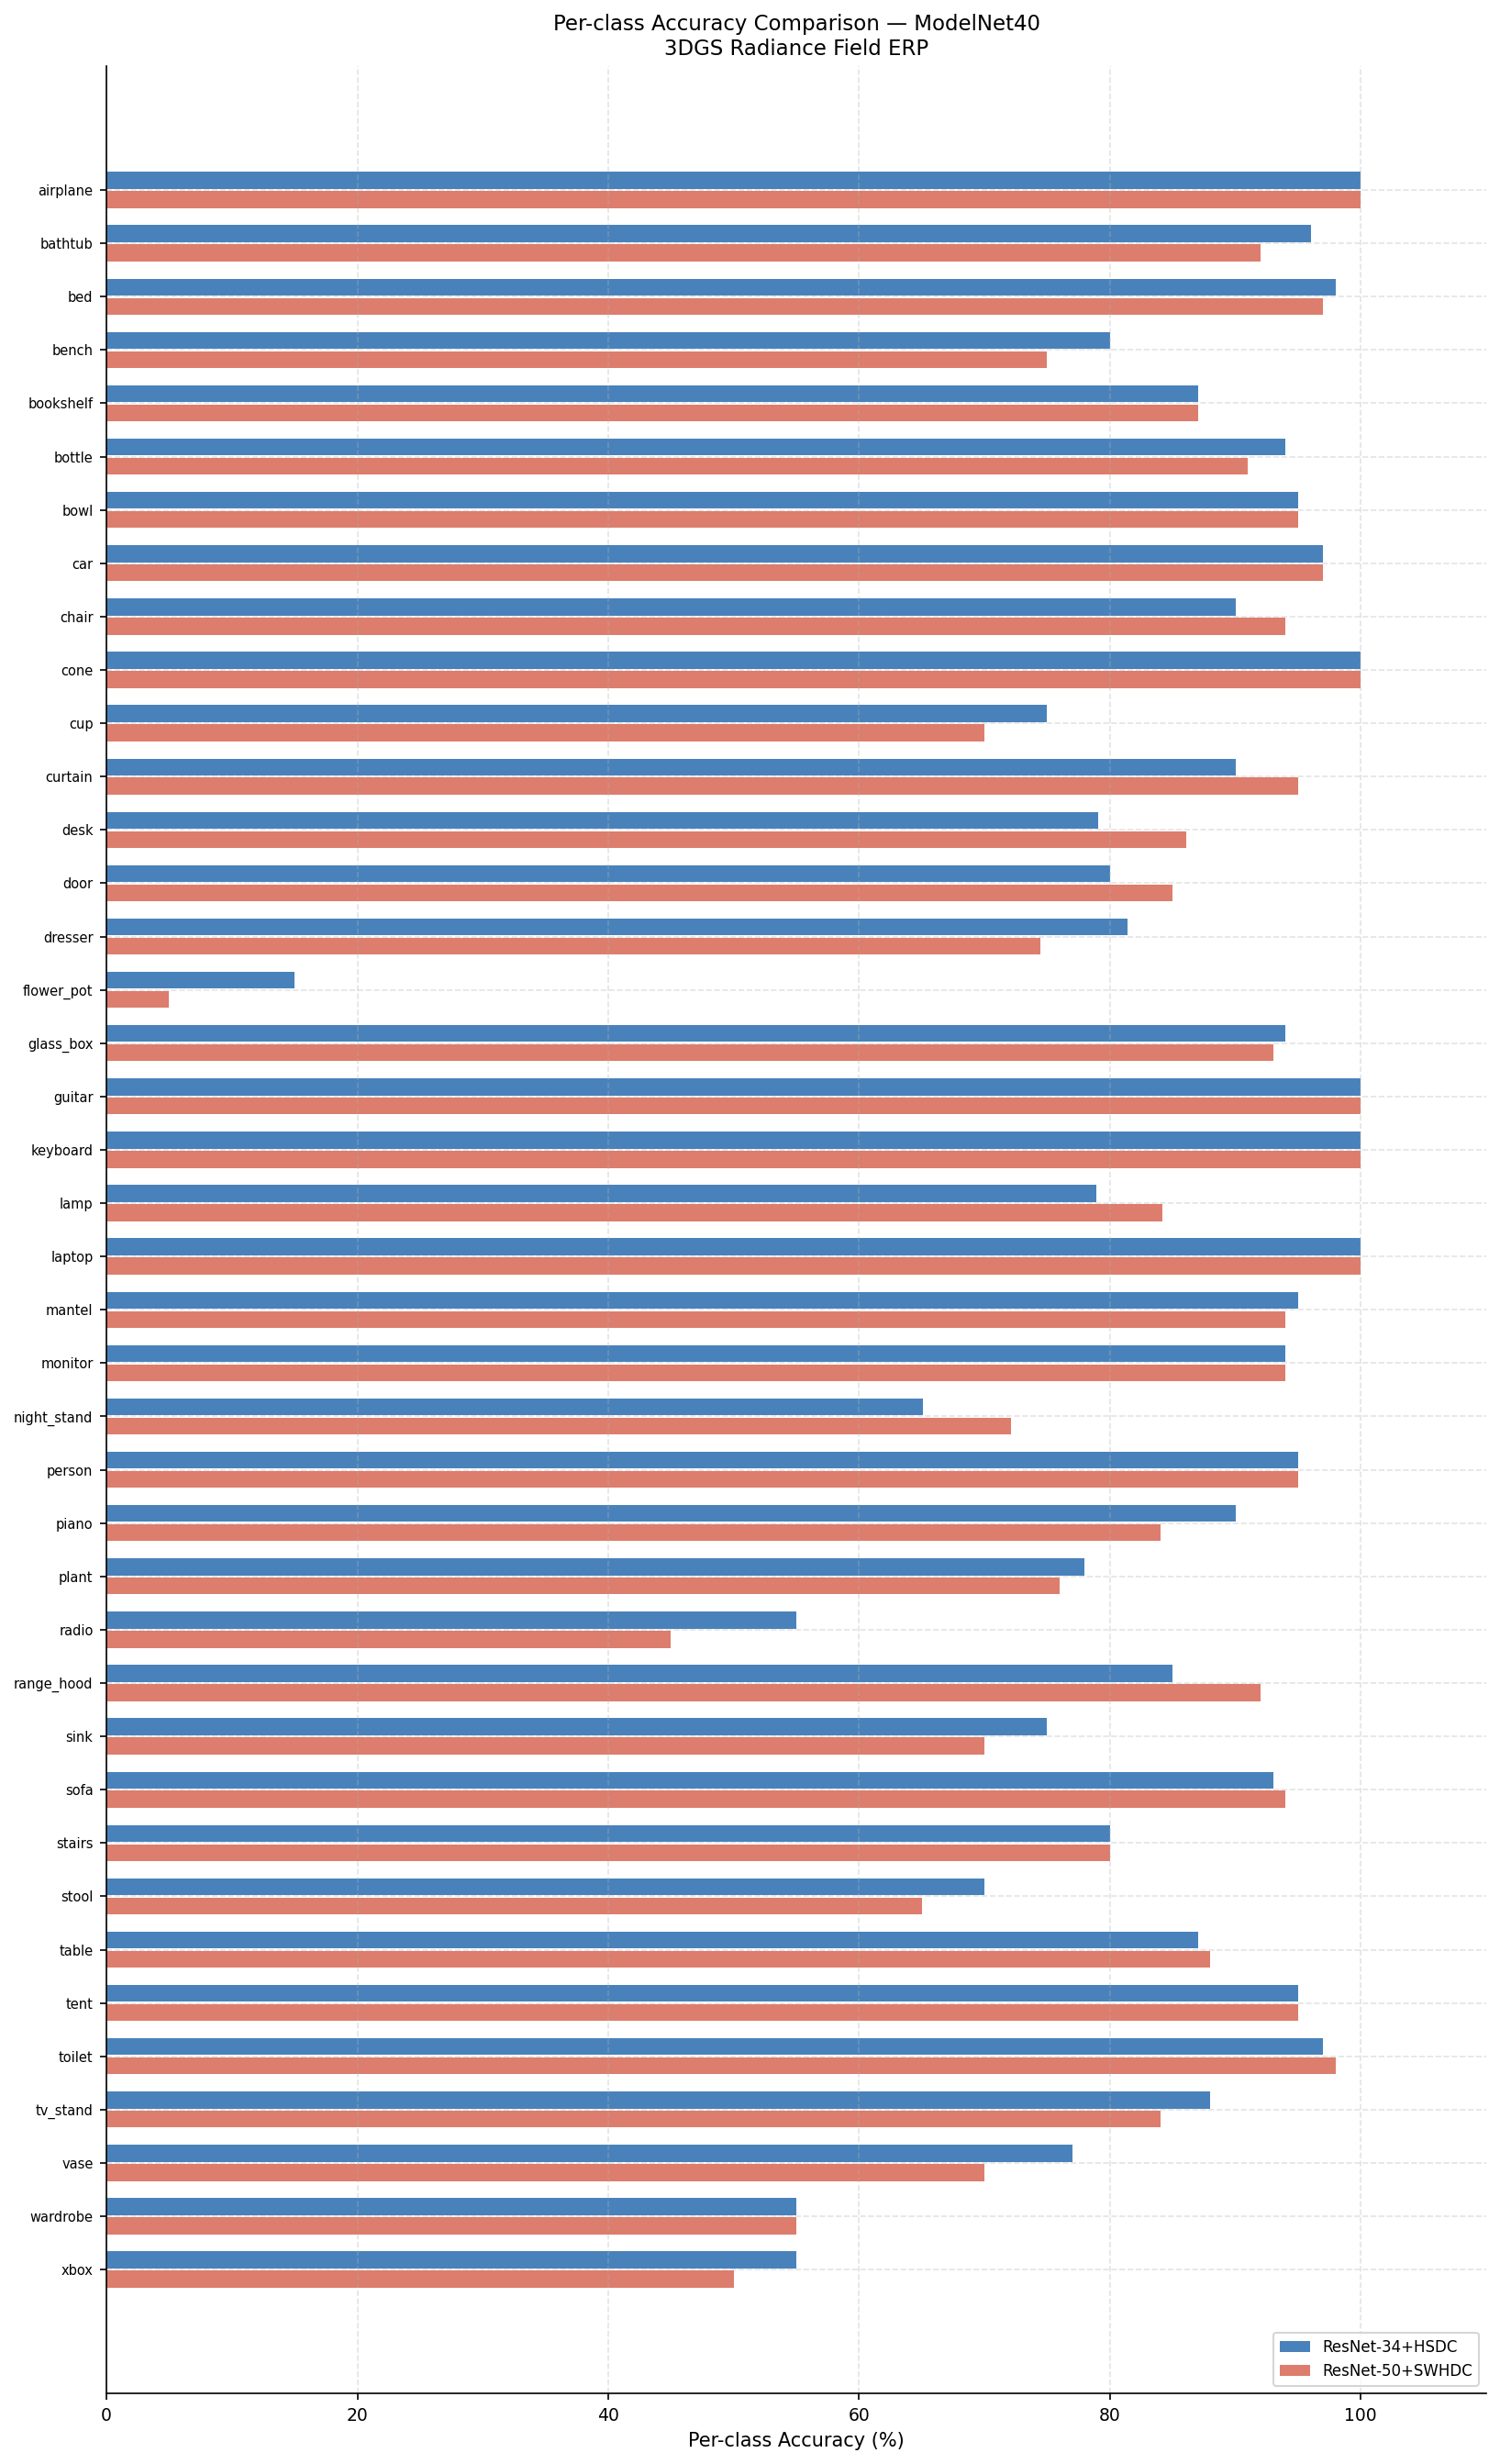

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/per_class_comparison_mn40.*


In [39]:
# Per-class accuracy charts, split by dataset.
# MN10: grouped horizontal bar chart comparing 2 models side-by-side.
# MN40: single-model horizontal bar chart (one MN40 run completed;
#        falls back to a grouped chart if multiple MN40 runs exist).

if not runs:
    print('No runs available.')
else:
    # Collect per-class data keyed by dataset
    mn10_results = {}   # label -> (per_class_array, class_names, run_name)
    mn40_results = {}

    for run_name, entry in runs.items():
        y_true = entry.get('y_true')
        y_pred = entry.get('y_pred')
        if y_true is None or y_pred is None:
            continue
        test        = entry.get('test') or {}
        n_cls       = int(test.get('num_classes', int(y_true.max()) + 1))
        class_names = class_names_for(n_cls)
        per_class   = compute_per_class_accuracy(y_true, y_pred, n_cls)
        _, _, label = _run_style(run_name)

        if 'mn10' in run_name.lower():
            mn10_results[label] = (per_class, class_names, run_name)
        elif 'mn40' in run_name.lower():
            mn40_results[label] = (per_class, class_names, run_name)

    # --- MN10: grouped comparison (2+ models) or single-model bar chart ---
    if len(mn10_results) >= 2:
        ref_label = next(iter(mn10_results))
        _, class_names, _ = mn10_results[ref_label]
        n_cls = len(class_names)

        labels_list = list(mn10_results.keys())
        n_models    = len(labels_list)
        bar_h       = 0.72 / n_models
        y_pos       = np.arange(n_cls)
        offsets     = np.linspace(
            -(n_models - 1) * bar_h / 2,
             (n_models - 1) * bar_h / 2,
            n_models,
        )

        fig, ax = plt.subplots(figsize=(11, max(5, n_cls * 0.60)))

        for idx, (label, (per_class, _, run_name)) in enumerate(mn10_results.items()):
            color = COLORS['hsdc'] if 'HSDC' in label else COLORS['swhdc']
            pct   = per_class * 100
            bars  = ax.barh(
                y_pos + offsets[idx], pct,
                height=bar_h * 0.88,
                color=color, alpha=0.82,
                label=label,
            )
            for bar, v in zip(bars, pct):
                ax.text(
                    bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.0f}%',
                    va='center', fontsize=7.5, color=color,
                )

        for label, (per_class, _, _) in mn10_results.items():
            color    = COLORS['hsdc'] if 'HSDC' in label else COLORS['swhdc']
            mean_acc = per_class.mean() * 100
            ax.axvline(mean_acc, color=color, linestyle='--', linewidth=1.2, alpha=0.7,
                       label=f'{label} mean: {mean_acc:.1f}%')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(class_names, fontsize=9)
        ax.set_xlabel('Per-class Accuracy (%)')
        ax.set_title(
            'Per-class Accuracy Comparison \u2014 ModelNet10\n'
            '3DGS Radiance Field ERP'
        )
        ax.set_xlim(0, 110)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, axis='x', linestyle='--', alpha=0.35)
        ax.invert_yaxis()

        plt.tight_layout()
        for ext in ('png', 'pdf'):
            fig.savefig(
                FIGURES_DIR / f'per_class_comparison_mn10.{ext}',
                dpi=300, bbox_inches='tight',
            )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/per_class_comparison_mn10.*')

        items = list(mn10_results.items())
        if len(items) >= 2:
            lbl_a, (pc_a, cls_names, _) = items[0]
            lbl_b, (pc_b, _, _)         = items[1]
            diff = (pc_a - pc_b) * 100
            print(f'\nClass-level comparison ({lbl_a} - {lbl_b}):')
            for cls, d in sorted(zip(cls_names, diff), key=lambda x: -abs(x[1])):
                winner = lbl_a if d > 0 else (lbl_b if d < 0 else 'tie')
                print(f'  {cls:15s}: {d:+.1f} pp  -> {winner} wins')

    elif len(mn10_results) == 1:
        label, (per_class, class_names, _) = next(iter(mn10_results.items()))
        fig = plot_per_class_accuracy(
            per_class, class_names, run_label=label,
            save_path=FIGURES_DIR / 'per_class_comparison_mn10',
        )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/per_class_comparison_mn10.*')
    else:
        print('No MN10 runs with predictions found.')

    print()

    # --- MN40: single-model bar chart; grouped if multiple MN40 runs ---
    if len(mn40_results) == 1:
        label, (per_class, class_names, _) = next(iter(mn40_results.items()))
        fig = plot_per_class_accuracy(
            per_class, class_names, run_label=f'{label} (ModelNet40)',
            save_path=FIGURES_DIR / 'per_class_accuracy_mn40',
        )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/per_class_accuracy_mn40.*')

    elif len(mn40_results) >= 2:
        ref_label = next(iter(mn40_results))
        _, class_names_40, _ = mn40_results[ref_label]
        n_cls40 = len(class_names_40)

        labels_40  = list(mn40_results.keys())
        n_models40 = len(labels_40)
        bar_h40    = 0.72 / n_models40
        y_pos40    = np.arange(n_cls40)
        offsets40  = np.linspace(
            -(n_models40 - 1) * bar_h40 / 2,
             (n_models40 - 1) * bar_h40 / 2,
            n_models40,
        )

        fig40, ax40 = plt.subplots(figsize=(11, max(8, n_cls40 * 0.45)))
        for idx, (lbl, (pc, _, run_name)) in enumerate(mn40_results.items()):
            color = COLORS['hsdc'] if 'HSDC' in lbl else COLORS['swhdc']
            pct   = pc * 100
            ax40.barh(
                y_pos40 + offsets40[idx], pct,
                height=bar_h40 * 0.88,
                color=color, alpha=0.82, label=lbl,
            )
        ax40.set_yticks(y_pos40)
        ax40.set_yticklabels(class_names_40, fontsize=7)
        ax40.set_xlabel('Per-class Accuracy (%)')
        ax40.set_title(
            'Per-class Accuracy Comparison \u2014 ModelNet40\n'
            '3DGS Radiance Field ERP'
        )
        ax40.set_xlim(0, 110)
        ax40.legend(loc='lower right', fontsize=8)
        ax40.grid(True, axis='x', linestyle='--', alpha=0.35)
        ax40.invert_yaxis()
        plt.tight_layout()
        for ext in ('png', 'pdf'):
            fig40.savefig(
                FIGURES_DIR / f'per_class_comparison_mn40.{ext}',
                dpi=300, bbox_inches='tight',
            )
        plt.show()
        print(f'Saved: {FIGURES_DIR}/per_class_comparison_mn40.*')
    else:
        print('No MN40 runs with predictions found.')


---
## Section 8: Parameter-Accuracy Pareto Plot (MN10)

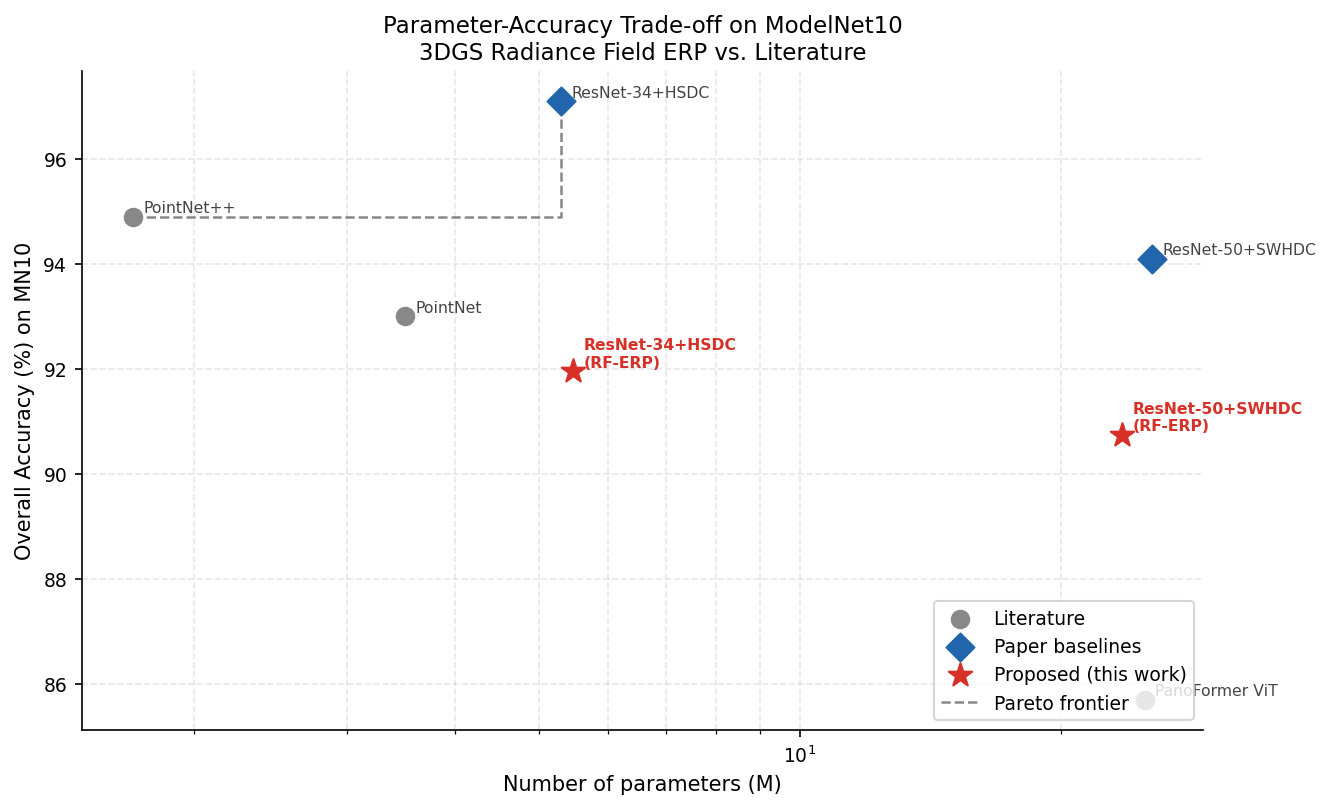

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/pareto_mn10.*

Proposed methods — MN10 (this work):
  ResNet-34+HSDC (RF-ERP): 5.47M params, 91.96% OA
  ResNet-50+SWHDC (RF-ERP): 23.55M params, 90.75% OA



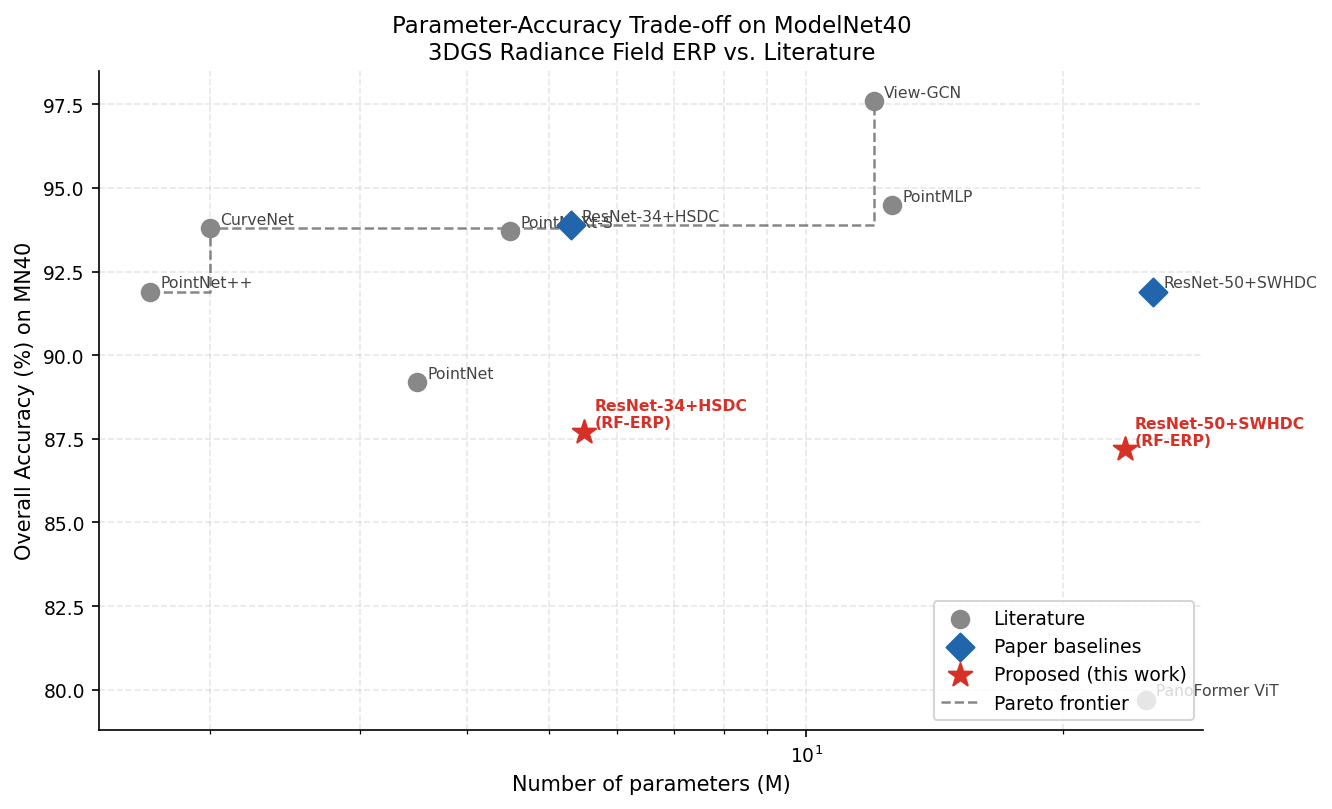

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/pareto_mn40.*

Proposed methods — MN40 (this work):
  ResNet-34+HSDC (RF-ERP): 5.49M params, 87.72% OA
  ResNet-50+SWHDC (RF-ERP): 23.61M params, 87.19% OA


In [40]:
# Auto-populate proposed dicts from completed runs, then draw Pareto plots
# for MN10 and MN40 separately.
# Shows where 3DGS RF-ERP sits relative to each dataset's literature landscape.

proposed_mn10 = {}
proposed_mn40 = {}

for run_name, entry in runs.items():
    test = entry.get('test')
    if test is None:
        continue
    oa     = _oa_to_pct(test.get('oa'))
    params = test.get('params_m', float('nan'))
    _, _, label = _run_style(run_name)
    point = (params, oa)

    if 'mn10' in run_name.lower():
        proposed_mn10[f'{label}\n(RF-ERP)'] = point
    elif 'mn40' in run_name.lower():
        proposed_mn40[f'{label}\n(RF-ERP)'] = point

# --- MN10 Pareto ---
fig_mn10 = plot_pareto(
    proposed=proposed_mn10,
    dataset='MN10',
    title='Parameter-Accuracy Trade-off on ModelNet10\n3DGS Radiance Field ERP vs. Literature',
    save_path=FIGURES_DIR / 'pareto_mn10',
)
plt.show()
print(f'Saved: {FIGURES_DIR}/pareto_mn10.*')

if proposed_mn10:
    print('\nProposed methods \u2014 MN10 (this work):')
    for lbl, (p, a) in proposed_mn10.items():
        print(f'  {lbl.replace(chr(10), " ")}: {p:.2f}M params, {a:.2f}% OA')
else:
    print('No MN10 runs found \u2014 Pareto shows literature only.')

print()

# --- MN40 Pareto ---
fig_mn40 = plot_pareto(
    proposed=proposed_mn40,
    dataset='MN40',
    title='Parameter-Accuracy Trade-off on ModelNet40\n3DGS Radiance Field ERP vs. Literature',
    save_path=FIGURES_DIR / 'pareto_mn40',
)
plt.show()
print(f'Saved: {FIGURES_DIR}/pareto_mn40.*')

if proposed_mn40:
    print('\nProposed methods \u2014 MN40 (this work):')
    for lbl, (p, a) in proposed_mn40.items():
        print(f'  {lbl.replace(chr(10), " ")}: {p:.2f}M params, {a:.2f}% OA')
else:
    print('No MN40 runs found \u2014 Pareto shows literature only.')


---
## Section 9: ERP Channel Visualisation

In [41]:
# Show 8-shell radiance field ERP for one sample per class.
# Loads from data/processed/modelnet10/radiance_field/ cache.
# Gracefully handles missing cache.

mn10_cache = DATA_CACHE_DIR / "modelnet10" / "radiance_field"

if not mn10_cache.exists():
    print(f"ERP cache not found at {mn10_cache}.")
    print("Run preprocessing first to generate cached ERPs:")
    print("  python -m src.preprocessing.dataset --config configs/resnet34_hsdc_mn10.yaml")
else:
    print(f"Loading ERP samples from: {mn10_cache}")

    # Discover one .npy file per class
    class_samples = {}
    for npy_path in sorted(mn10_cache.rglob("*.npy")):
        # Expected layout: <cache_dir>/<class>/<split>/<name>.npy
        parts = npy_path.relative_to(mn10_cache).parts
        cls = parts[0] if len(parts) >= 1 else None
        if cls is not None and cls in MODELNET10_CLASSES and cls not in class_samples:
            class_samples[cls] = npy_path

    if not class_samples:
        print("No .npy files found in cache. Check directory structure.")
    else:
        print(f"Found {len(class_samples)} class(es) with cached ERPs.")

        for cls_name in MODELNET10_CLASSES:
            if cls_name not in class_samples:
                print(f"  No sample found for class '{cls_name}', skipping.")
                continue

            erp = np.load(str(class_samples[cls_name]))  # (N_shells, H, W)
            N, H, W = erp.shape

            n_cols = min(4, N)
            n_rows = int(np.ceil(N / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 2.5))
            axes = np.array(axes).flatten() if N > 1 else [axes]

            fig.suptitle(
                f"Radiance Field ERP — class: {cls_name} | {N} shells | {H}x{W}",
                fontsize=10, y=1.01,
            )

            # Channel labels: d_1, d_2, ... d_N
            shell_labels = [f"Shell d_{s+1}" for s in range(N)]

            for s in range(N):
                im = axes[s].imshow(erp[s], cmap="viridis", aspect="auto")
                axes[s].set_title(shell_labels[s], fontsize=8)
                axes[s].axis("off")
                plt.colorbar(im, ax=axes[s], fraction=0.03, pad=0.02)

            for a in axes[N:]:
                a.set_visible(False)

            plt.tight_layout()
            save_stem = FIGURES_DIR / f"erp_channels_{cls_name}"
            for ext in ("png", "pdf"):
                fig.savefig(save_stem.with_suffix(f".{ext}"), dpi=300, bbox_inches="tight")
            plt.show()
            plt.close(fig)

        print(f"\nERP channel figures saved to {FIGURES_DIR}/erp_channels_*.")

Loading ERP samples from: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\data\processed\modelnet10\radiance_field
No .npy files found in cache. Check directory structure.


---
## Section 10: Grad-CAM Attention Maps

In [42]:
# Grad-CAM for the last convolutional layer.
# Requires: pip install pytorch-grad-cam
# Gracefully skipped if not installed or no cache available.

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
    print("pytorch-grad-cam is available.")
except ImportError:
    GRADCAM_AVAILABLE = False
    print("pytorch-grad-cam not installed. Skipping Grad-CAM section.")
    print("Install with: pip install pytorch-grad-cam")

if GRADCAM_AVAILABLE:
    import torch
    print("\nGrad-CAM section requires model loading. Skeleton below:")
    print("Uncomment and adapt for your backbone once the Grad-CAM run is configured.")
    print()

    for run_name, entry in runs.items():
        ckpt_path = find_best_checkpoint(entry["run_dir"])
        if ckpt_path is None:
            print(f"  No checkpoint found for {run_name}.")
            continue
        print(f"  Checkpoint available for {run_name}: {ckpt_path.name}")

    print()
    print("Example Grad-CAM usage for ResNet-34+HSDC:")
    print("""
    import torch
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from src.models.backbones.resnet_hsdc import HSDCNet

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = HSDCNet(in_channels=10, num_classes=10).to(device)
    ckpt   = torch.load("experiments/resnet34_hsdc_mn10_seed42/best_checkpoint.pt", map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    target_layers = [model.layer4[-1]]  # last ResNet block
    cam = GradCAM(model=model, target_layers=target_layers)

    erp_np = np.load("<path_to_npy_sample>")  # (N_shells, H, W)
    inp    = torch.tensor(erp_np).unsqueeze(0).float().to(device)

    grayscale_cam = cam(inp, targets=[ClassifierOutputTarget(class_idx)])[0]

    fig = plot_gradcam(
        grayscale_cam=grayscale_cam,
        erp=erp_np,
        class_name="chair",
        pred_class="chair",
        save_path=FIGURES_DIR / "gradcam_resnet34_hsdc_mn10_seed42_chair",
    )
    """)

pytorch-grad-cam not installed. Skipping Grad-CAM section.
Install with: pip install pytorch-grad-cam


---
## Section 11: Ablation Studies

--- Ablation: Effect of N dilation rates (SWHDC paper Table II) ---
Source: Stringhini et al., SIBGRAPI 2024



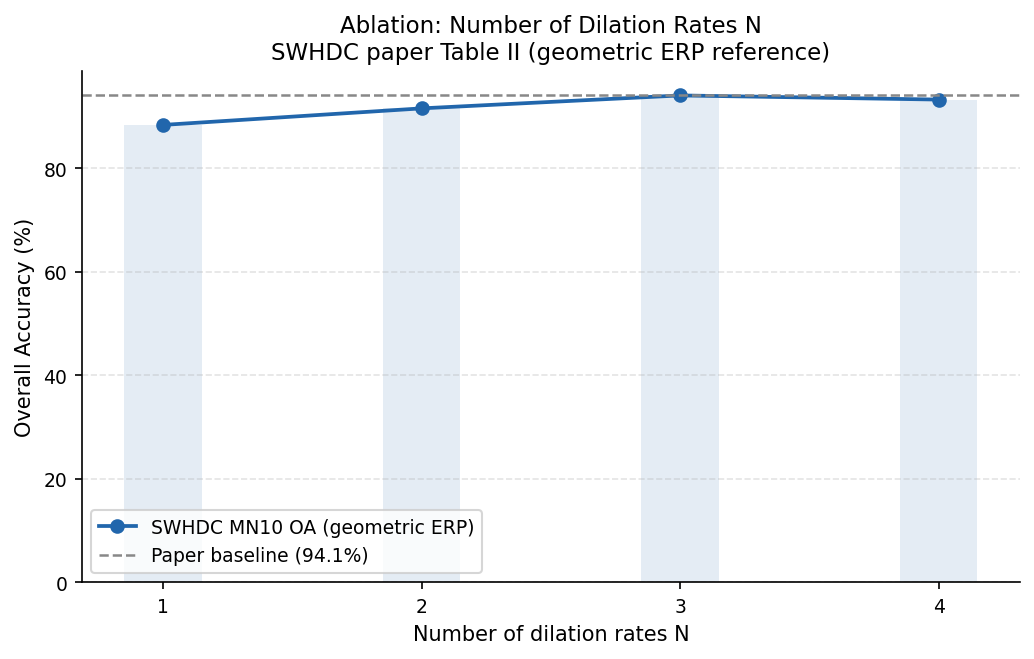

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/ablation_n_dilation_rates.*


In [43]:
# Ablation 1: Effect of N dilation rates (SWHDC paper Table II).
# These are the geometric-ERP reference numbers from the paper.
# Use this plot to contextualize your 3DGS ERP results in the TCC.

print("--- Ablation: Effect of N dilation rates (SWHDC paper Table II) ---")
print("Source: Stringhini et al., SIBGRAPI 2024")
print()

ablation_n_rates = {
    "SWHDC MN10 OA (geometric ERP)": [88.4, 91.6, 94.1, 93.3],  # N=1,2,3,4
}

fig = plot_ablation(
    data=ablation_n_rates,
    x_labels=[1, 2, 3, 4],
    x_label="Number of dilation rates N",
    y_label="Overall Accuracy (%)",
    title="Ablation: Number of Dilation Rates N\nSWHDC paper Table II (geometric ERP reference)",
    baseline=94.1,
    save_path=FIGURES_DIR / "ablation_n_dilation_rates",
)
plt.show()
print(f"Saved: {FIGURES_DIR}/ablation_n_dilation_rates.*")

--- Ablation: Effect of ERP resolution (HSDC paper Table 4) ---
Source: Stringhini et al., IEEE ICIP 2024



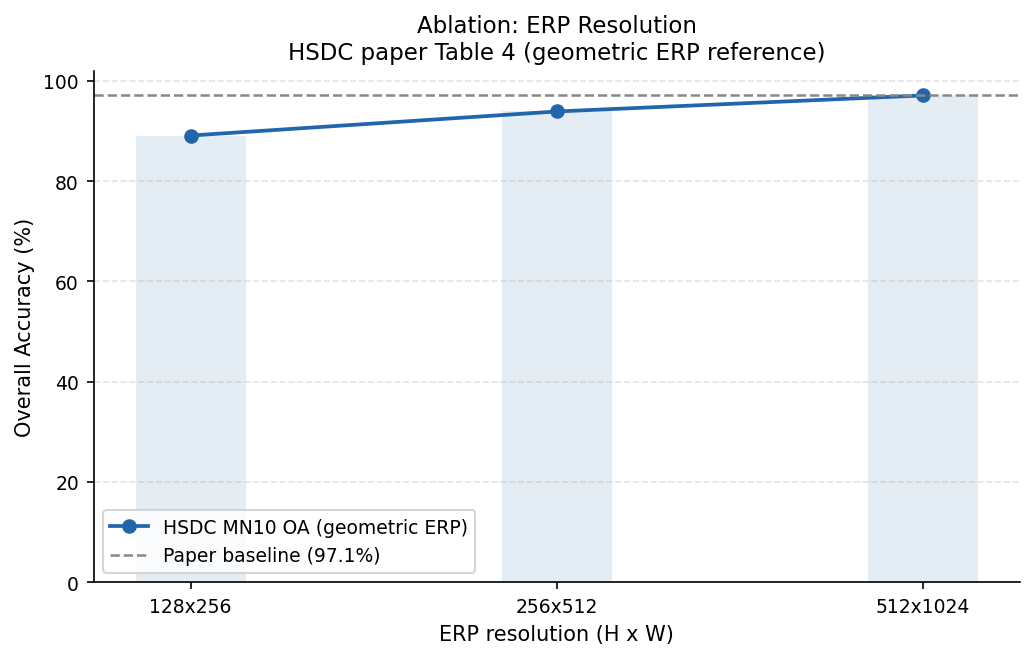

Saved: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures/ablation_erp_resolution.*


In [44]:
# Ablation 2: Effect of ERP resolution (HSDC paper Table 4).

print("--- Ablation: Effect of ERP resolution (HSDC paper Table 4) ---")
print("Source: Stringhini et al., IEEE ICIP 2024")
print()

ablation_resolution = {
    "HSDC MN10 OA (geometric ERP)": [89.1, 93.9, 97.1],  # 128x256, 256x512, 512x1024
}

fig = plot_ablation(
    data=ablation_resolution,
    x_labels=["128x256", "256x512", "512x1024"],
    x_label="ERP resolution (H x W)",
    y_label="Overall Accuracy (%)",
    title="Ablation: ERP Resolution\nHSDC paper Table 4 (geometric ERP reference)",
    baseline=97.1,
    save_path=FIGURES_DIR / "ablation_erp_resolution",
)
plt.show()
print(f"Saved: {FIGURES_DIR}/ablation_erp_resolution.*")

In [45]:
# Ablation 3: Effect of number of radiance field shells (new contribution).
# Fill in once multi-shell experiments are complete.

print("--- Ablation: Effect of N radiance field shells (3DGS RF-ERP) ---")
print("Placeholder — fill with actual multi-shell experiment results.")
print()

# Example structure (uncomment when multi-shell experiments are done):
# ablation_shells = {
#     "ResNet-34+HSDC MN10 OA": [85.0, 88.2, 90.5, 91.96],  # N=2, 4, 6, 8
#     "ResNet-50+SWHDC MN10 OA": [83.0, 87.0, 89.0, 90.75],
# }
# fig = plot_ablation(
#     data=ablation_shells,
#     x_labels=[2, 4, 6, 8],
#     x_label="Number of radiance field shells",
#     y_label="Overall Accuracy (%)",
#     title="Ablation: Number of 3DGS Radiance Field Shells (ModelNet10)",
#     save_path=FIGURES_DIR / "ablation_n_shells",
# )
# plt.show()

print("Ablation template ready. Uncomment block above when multi-shell experiments are done.")

--- Ablation: Effect of N radiance field shells (3DGS RF-ERP) ---
Placeholder — fill with actual multi-shell experiment results.

Ablation template ready. Uncomment block above when multi-shell experiments are done.


---
## Section 12: Statistical Significance (McNemar's Test)

In [46]:
# McNemar's test: correct choice for two models evaluated on the same fixed test set.
# Uses exact binomial test (conservative, recommended when b+c < 25).
# H_0: the two classifiers have the same error rate on the test set.

if not runs:
    print("No runs available.")
else:
    # Separate by dataset
    runs_mn10 = {
        k: v for k, v in runs.items()
        if "mn10" in k.lower() and v.get("y_true") is not None
    }
    runs_mn40 = {
        k: v for k, v in runs.items()
        if "mn40" in k.lower() and v.get("y_true") is not None
    }

    for ds_name, ds_runs in [("MN10", runs_mn10), ("MN40", runs_mn40)]:
        if len(ds_runs) < 2:
            print(f"{ds_name}: fewer than 2 runs with predictions — skipping McNemar.")
            if ds_runs:
                print(f"  Available: {list(ds_runs.keys())}")
            print()
            continue

        # Ground truth must be the same for McNemar to be valid.
        # For the official ModelNet split, all runs use the same test set.
        ref_entry = next(iter(ds_runs.values()))
        y_target  = ref_entry["y_true"]

        print(f"=== {ds_name}: McNemar p-value matrix (exact binomial, two-sided) ===")
        print(f"Test set: {len(y_target)} samples")
        print("H_0: models have the same error rate.  Reject at p < 0.05 (*).")
        print()

        mcnemar_df = build_mcnemar_table(ds_runs, y_target)

        if mcnemar_df.empty:
            print("Could not build McNemar table.")
        else:
            display(mcnemar_df.round(4))
            print()
            names = list(mcnemar_df.columns)
            for i in range(len(names)):
                for j in range(i + 1, len(names)):
                    p   = mcnemar_df.iloc[i, j]
                    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
                    print(f"  {names[i]} vs {names[j]}: p={p:.4f} {sig}")
        print()

=== MN10: McNemar p-value matrix (exact binomial, two-sided) ===
Test set: 908 samples
H_0: models have the same error rate.  Reject at p < 0.05 (*).



,resnet34_hsdc_mn10_seed42,resnet50_swhdc_mn10_seed42
resnet34_hsdc_mn10_seed42,1.0000,0.1263
resnet50_swhdc_mn10_seed42,0.1263,1.0000



  resnet34_hsdc_mn10_seed42 vs resnet50_swhdc_mn10_seed42: p=0.1263 ns

=== MN40: McNemar p-value matrix (exact binomial, two-sided) ===
Test set: 2467 samples
H_0: models have the same error rate.  Reject at p < 0.05 (*).



,resnet34_hsdc_mn40_seed42,resnet50_swhdc_mn40_seed42
resnet34_hsdc_mn40_seed42,1.000,0.332
resnet50_swhdc_mn40_seed42,0.332,1.000



  resnet34_hsdc_mn40_seed42 vs resnet50_swhdc_mn40_seed42: p=0.3320 ns



---
## Section 13: Multi-Seed Summary

In [47]:
# Aggregate runs sharing a common base name but different seeds.
# With a single seed, confirms the run is detected; std is undefined.
# With >= 3 seeds, report mean +/- std in TCC tables.

if not runs:
    print("No runs available.")
else:
    base_configs = [
        "resnet34_hsdc_mn10",
        "resnet50_swhdc_mn10",
        "resnet34_hsdc_mn40",
        "resnet50_swhdc_mn40",
    ]

    print("Multi-seed statistics (mean +/- std across seeds sharing the same base config):")
    print()

    multi_seed_rows = []
    for base in base_configs:
        stats = compute_multi_seed_stats(runs, base)
        n = stats["n_seeds"]
        if n == 0:
            print(f"  {base}: No completed runs found.")
            continue

        oa_mean  = stats["oa_mean"]
        oa_std   = stats["oa_std"]
        oa_str   = (f"{oa_mean:.2f}% (1 seed — std undefined)"
                    if n == 1 else f"{oa_mean:.2f} +/- {oa_std:.2f}% ({n} seeds)")

        mac_mean = stats["macc_mean"]
        mac_std  = stats["macc_std"]
        mac_str  = (f"{mac_mean:.2f}%" if (mac_mean is not None and n == 1)
                    else (f"{mac_mean:.2f} +/- {mac_std:.2f}%"
                          if (mac_mean is not None and n > 1)
                          else "N/A"))

        # Find paper target for this config
        target = None
        for key, val in PAPER_TARGETS.items():
            if key.replace("_", "") in base.replace("_", ""):
                target = val
                break

        print(f"  {base}:")
        print(f"    OA:           {oa_str}")
        print(f"    mAcc:         {mac_str}")
        if target is not None:
            gap = target - oa_mean
            print(f"    Paper target: {target}%  (gap: {gap:+.2f} pp)")
        print()

        multi_seed_rows.append({
            "Config":           base,
            "N Seeds":          n,
            "OA Mean (%)": round(oa_mean, 2) if oa_mean is not None else float("nan"),
            "OA Std (%)": round(oa_std, 2) if oa_std is not None else float("nan"),
            "mAcc Mean (%)": round(mac_mean, 2) if mac_mean is not None else float("nan"),
            "Paper Target (%)": target if target is not None else float("nan"),
        })

    if multi_seed_rows:
        print("Summary table:")
        ms_df = pd.DataFrame(multi_seed_rows)
        with pd.option_context("display.float_format", "{:.2f}".format):
            display(ms_df)

        print()
        print("Recommendations:")
        print("  - Run at least 3 seeds (seed42, seed0, seed1) for publishable mean +/- std.")
        print("  - Report mean +/- std in TCC Table when n_seeds >= 3.")
        print("  - Use paired t-test (scipy.stats.ttest_rel) when comparing two configurations")
        print("    across multiple seeds (requires same seeds for each config).")

Multi-seed statistics (mean +/- std across seeds sharing the same base config):

  resnet34_hsdc_mn10:
    OA:           91.96% (1 seed — std undefined)
    mAcc:         91.93%
    Paper target: 97.1%  (gap: +5.14 pp)

  resnet50_swhdc_mn10:
    OA:           90.75% (1 seed — std undefined)
    mAcc:         90.80%
    Paper target: 94.1%  (gap: +3.35 pp)

  resnet34_hsdc_mn40:
    OA:           87.72% (1 seed — std undefined)
    mAcc:         83.99%
    Paper target: 93.9%  (gap: +6.18 pp)

  resnet50_swhdc_mn40:
    OA:           87.19% (1 seed — std undefined)
    mAcc:         83.04%
    Paper target: 91.9%  (gap: +4.71 pp)

Summary table:


,Config,N Seeds,OA Mean (%),OA Std (%),mAcc Mean (%),Paper Target (%)
0,resnet34_hsdc_mn10,1,91.96,NaN,91.93,97.10
1,resnet50_swhdc_mn10,1,90.75,NaN,90.80,94.10
2,resnet34_hsdc_mn40,1,87.72,NaN,83.99,93.90
3,resnet50_swhdc_mn40,1,87.19,NaN,83.04,91.90



Recommendations:
  - Run at least 3 seeds (seed42, seed0, seed1) for publishable mean +/- std.
  - Report mean +/- std in TCC Table when n_seeds >= 3.
  - Use paired t-test (scipy.stats.ttest_rel) when comparing two configurations
    across multiple seeds (requires same seeds for each config).


---
## Summary: Generated Outputs

In [48]:
print("=" * 70)
print("OUTPUTS GENERATED BY THIS NOTEBOOK")
print("=" * 70)
print()

print(f"Figures directory: {FIGURES_DIR}")
figs = sorted(FIGURES_DIR.glob("*.png"))
if figs:
    for f in figs:
        size_kb = f.stat().st_size // 1024
        print(f"  {f.name}  ({size_kb} KB)")
else:
    print("  (none — run all cells above first)")

print()
print(f"Tables directory: {TABLES_DIR}")
tables = sorted(TABLES_DIR.glob("*.tex"))
if tables:
    for t in tables:
        print(f"  {t.name}")
else:
    print("  (none — run all cells above first)")

print()
print("Key metrics summary:")
for run_name, entry in runs.items():
    test    = entry.get("test") or {}
    oa_pct  = _oa_to_pct(test.get("oa"))
    target  = _get_paper_target(run_name)
    gap_str = f"{target - oa_pct:+.2f} pp" if target is not None else "N/A"
    print(f"  {run_name}:  OA={oa_pct:.2f}%  gap_from_paper={gap_str}")

OUTPUTS GENERATED BY THIS NOTEBOOK

Figures directory: c:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures
  ablation_erp_resolution.png  (109 KB)
  ablation_n_dilation_rates.png  (107 KB)
  accuracy_comparison.png  (120 KB)
  confusion_matrix_resnet34_hsdc_mn10_seed42.png  (202 KB)
  confusion_matrix_resnet34_hsdc_mn40_seed42.png  (462 KB)
  confusion_matrix_resnet50_swhdc_mn10_seed42.png  (201 KB)
  confusion_matrix_resnet50_swhdc_mn40_seed42.png  (463 KB)
  convergence_thresholds.png  (129 KB)
  convergence_thresholds_mn10.png  (129 KB)
  convergence_thresholds_mn40.png  (119 KB)
  gap_analysis_mn10.png  (123 KB)
  gap_analysis_mn40.png  (126 KB)
  generalization_gap.png  (330 KB)
  lr_schedule.png  (204 KB)
  pareto_mn10.png  (168 KB)
  pareto_mn40.png  (191 KB)
  per_class_acc_resnet34_hsdc_mn10_seed42.png  (112 KB)
  per_class_acc_resnet34_hsdc_mn40_seed42.png  (325 KB)
  per_class_acc_resnet50_swhdc_mn10_seed42.png  (112 KB)
  per_class_acc_resnet50_swhdc_mn